In [1]:
from pathlib import Path
from datetime import datetime, timedelta
import re
import xarray as xr
import rioxarray as rxr
import numpy as np
import pandas as pd
import gc
from dataclasses import dataclass, field
from typing import Generator
import json
from scipy.integrate import trapezoid

import geopandas as gpd
from functools import partial
from scipy import stats
from typing import Callable
import matplotlib.pyplot as plt
from typing import Optional

import time
from scipy.integrate import trapezoid
import os
import tempfile
# import time as timer
from joblib import Parallel, delayed

import warnings
warnings.filterwarnings('ignore', message='invalid value encountered in cast')

from phenometrics_utils import *
from scipy.interpolate import LSQUnivariateSpline

from scipy.interpolate import LSQUnivariateSpline, UnivariateSpline

In [2]:
# reload modules during block executions for active dev in phenometrics_utils.py
# %reload_ext autoreload
%load_ext autoreload
%autoreload 2    

In [3]:
def save_spline_comparison_netcdf(pre_spline: xr.DataArray, 
                                   post_spline: xr.DataArray,
                                   central_year: int,
                                   output_dir: Path,
                                   y_coords: np.ndarray,
                                   x_coords: np.ndarray,
                                   crs: str):
    """Save pre/post spline comparison as NetCDF."""
    
    if output_dir is None:
        output_dir = Path(f"./spline_comparison_{central_year}")
    output_dir.mkdir(exist_ok=True, parents=True)
    
    print(f"\n=== Saving spline comparison as NetCDF ===")
    print(f"  Pre-spline shape: {pre_spline.shape}")
    print(f"  Post-spline shape: {post_spline.shape}")
    
    # Ensure both have proper coordinates
    if not hasattr(pre_spline, 'y') or len(pre_spline.y) != len(y_coords):
        pre_spline = pre_spline.assign_coords(y=y_coords, x=x_coords)
    if not hasattr(post_spline, 'y') or len(post_spline.y) != len(y_coords):
        post_spline = post_spline.assign_coords(y=y_coords, x=x_coords)
    
    # Create dataset with multiple variables
    ds = xr.Dataset({
        'evi_raw': pre_spline.rename('evi_raw'),
        'evi_smoothed': post_spline.rename('evi_smoothed'),
        'difference': (post_spline - pre_spline).rename('difference'),
    })
    
    # Add CRS and metadata
    ds.attrs['crs'] = crs
    ds.attrs['central_year'] = central_year
    ds.attrs['description'] = f'EVI spline smoothing comparison for {central_year}'
    ds.attrs['created'] = pd.Timestamp.now().isoformat()
    
    # Add variable descriptions
    ds['evi_raw'].attrs['long_name'] = 'Raw EVI (after despiking)'
    ds['evi_raw'].attrs['units'] = 'dimensionless'
    
    ds['evi_smoothed'].attrs['long_name'] = 'Spline-smoothed EVI'
    ds['evi_smoothed'].attrs['units'] = 'dimensionless'
    
    ds['difference'].attrs['long_name'] = 'Smoothing residuals'
    ds['difference'].attrs['description'] = 'evi_smoothed - evi_raw'
    ds['difference'].attrs['units'] = 'dimensionless'
    
    # Save
    output_file = output_dir / f"spline_comparison_{central_year}.nc"
    ds.to_netcdf(output_file, mode = 'w')
    
    print(f"  Saved NetCDF: {output_file}")
    print(f"  Variables: {list(ds.data_vars)}")
    print(f"  Dimensions: {dict(ds.dims)}")
    
    return output_file

def plot_spline_comparison(ds, yi, xi, target_year=None, outdir=None):
    """
    Plot raw vs smoothed EVI with proper NaN handling.
    
    Args:
        ds: xarray Dataset with evi_raw, evi_smoothed, difference
        yi, xi: Pixel indices
        target_year: Optional year to highlight
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Extract and drop NaN separately for each variable
    raw = ds['evi_raw'].isel(y=yi, x=xi).dropna(dim='time')
    smoothed = ds['evi_smoothed'].isel(y=yi, x=xi).dropna(dim='time')
    diff = ds['difference'].isel(y=yi, x=xi).dropna(dim='time')
    
    # --- Time series ---
    ax1.plot(raw.time.values, raw.values, 'o', 
             markersize=5, alpha=0.8, color='C0', label='Raw')
    ax1.plot(smoothed.time.values, smoothed.values, '-', 
             linewidth=2, color='C1', label='Smoothed')
    
    # Add year boundaries
    if target_year:
        ax1.axvline(pd.Timestamp(f'{target_year}-01-01'), color='black', 
                   linestyle='--', linewidth=2, alpha=0.9)
        ax1.axvline(pd.Timestamp(f'{target_year}-12-31'), color='black', 
                   linestyle='--', linewidth=2, alpha=0.9)
    
    ax1.set_title(f'Pixel ({yi}, {xi}) - EVI Time Series')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('EVI')
    diff_target_year = diff.sel(time = str(target_year))
    rmse = np.sqrt(np.nanmean(diff_target_year.values ** 2))
    mae = np.nanmean(np.abs(diff_target_year.values))
    # mbe = np.nanmean(diff.values)
    
    stats_text = f'RMSE: {rmse:.4f}\nMAE: {mae:.4f}'
    ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax1.legend()
    
    ymin = np.nanmin(raw.values)
    ymax = np.nanmax(raw.values)
    padding = (ymax - ymin) * 0.1

    ax1.set_ylim(ymin - padding, ymax + padding)
    ax1.grid(True, alpha=0.3)
    
    # --- Residuals ---
    ax2.plot(diff.time.values, diff.values, 'o', markersize=4, alpha=0.7)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    
    # Add stats   
    ax2.set_title('Smoothing Residuals')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Residual (Smoothed - Raw)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if outdir:
        plt.savefig(f'{outdir}/pixel_comparison-y{yi}_x{xi}.png', dpi=500)
    plt.show()
    
    # Print data summary
    print(f"\nPixel ({yi}, {xi}) summary:")
    print(f"  Raw: {len(raw)} valid of {len(ds.time)} timesteps")
    print(f"  Smoothed: {len(smoothed)} valid")
    print(f"  RMSE: {rmse:.4f}, MAE: {mae:.4f}")


def plot_pixel_phenometrics(ds, chunk_results, yi=0, xi=1, target_year=2019):
    """Plot raw/smoothed EVI with all phenometric markers."""
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), 
                                    gridspec_kw={'height_ratios': [2, 2]})
    
    # Extract and drop NaN
    raw = ds['evi_raw'].isel(y=yi, x=xi).dropna(dim='time')
    smoothed = ds['evi_smoothed'].isel(y=yi, x=xi).dropna(dim='time')
    
    # Plot raw and smoothed
    ax1.plot(raw.time.values, raw.values, 'o', 
             markersize=5, alpha=0.5, color='C0', label='Raw')
    ax1.plot(smoothed.time.values, smoothed.values, '-', 
             linewidth=2, color='C1', label='Smoothed')
    
    def doy_to_date(doy):
        if np.isnan(doy):
            return None
        return pd.Timestamp(f"{target_year}-01-01") + pd.Timedelta(days=int(doy) - 1)
    
    def get_val(key):
        """Get metric value using key_YYYY format."""
        full_key = f"{key}_{target_year}"
        if full_key in chunk_results:
            arr = chunk_results[full_key]
            if arr.ndim == 3:
                return arr[0, yi, xi]
            elif arr.ndim == 2:
                return arr[yi, xi]
        return np.nan
    
    # Year boundaries
    ax1.axvline(pd.Timestamp(f'{target_year}-01-01'), color='black', 
               linestyle='--', linewidth=1, alpha=0.5)
    ax1.axvline(pd.Timestamp(f'{target_year}-12-31'), color='black', 
               linestyle='--', linewidth=1, alpha=0.5)
    
    # Threshold line
    thresh = get_val('greenup_threshold')
    if not np.isnan(thresh):
        ax1.axhline(thresh, color='gray', linestyle=':', alpha=0.8, linewidth = 2,
                    label=f'Threshold ({thresh:.3f})')
    
    # All DOY-based markers to plot
    markers = [
        ('greenup_doy', 'greenup_evi', 'v', 'limegreen', 'Greenup'),
        ('max_doy', 'max_evi', '^', 'red', 'Peak'),
        ('dormancy_doy', 'dormancy_evi', 'v', 'brown', 'Dormancy'),
        ('min_doy', 'min_evi', 's', 'blue', 'Min'),
        ('greenup_rate_doy', None, 'D', 'lime', 'Steepest Greenup'),
        ('senescence_rate_doy', None, 'D', 'orange', 'Steepest Senescence'),
    ]
    
    for doy_key, evi_key, marker, color, label in markers:
        doy_val = get_val(doy_key)
        if np.isnan(doy_val):
            continue
        
        date = doy_to_date(doy_val)
        if date is None:
            continue
        
        # Get EVI value
        if evi_key is not None:
            evi_val = get_val(evi_key)
        else:
            # Find closest smoothed value in target year
            target_doys = smoothed.time.dt.dayofyear.values
            target_years = smoothed.time.dt.year.values
            year_mask = target_years == target_year
            if year_mask.sum() > 0:
                year_doys = target_doys[year_mask]
                year_vals = smoothed.values[year_mask]
                closest_idx = np.argmin(np.abs(year_doys - doy_val))
                evi_val = year_vals[closest_idx]
            else:
                evi_val = np.nan
        
        if np.isnan(evi_val):
            continue
        
        # Build label with rate info if applicable
        if 'greenup_rate' in doy_key:
            rate = get_val('greenup_rate')
            label = f'{label} (DOY {doy_val:.0f}, {rate:.4f}/day)'
        elif 'senescence_rate' in doy_key:
            rate = get_val('senescence_rate')
            label = f'{label} (DOY {doy_val:.0f}, {rate:.4f}/day)'
        else:
            label = f'{label} (DOY {doy_val:.0f}, EVI {evi_val:.3f})'
        
        ax1.plot(date, evi_val, marker, color=color, markersize=12,
                markeredgecolor='black', markeredgewidth=1, zorder=10,
                label=label)
        ax1.axvline(date, color=color, linestyle=':', alpha=0.8, linewidth = 2)
    
    # AUC shading
    greenup_d = get_val('greenup_doy')
    dorm_d = get_val('dormancy_doy')
    min_e = get_val('min_evi')
    
    if not np.isnan(greenup_d) and not np.isnan(dorm_d) and not np.isnan(min_e):
        gs_mask = ((smoothed.time.dt.year == target_year) &
                   (smoothed.time.dt.dayofyear >= greenup_d) & 
                   (smoothed.time.dt.dayofyear <= dorm_d))
        gs_data = smoothed.where(gs_mask, drop=True)
        
        if len(gs_data) > 0:
            auc_net = get_val('auc_net')
            ax1.fill_between(gs_data.time.values, min_e, gs_data.values,
                           alpha=0.15, color='green',
                           label=f'AUC net ({auc_net:.1f})' if not np.isnan(auc_net) else 'AUC net')
    
    ax1.set_title(f'Pixel ({yi}, {xi}) - EVI Phenometrics {target_year}')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('EVI')
    ax1.legend(fontsize=7, loc='upper right', ncol=2)
    ax1.grid(True, alpha=0.3)
    
    # ================================================================
    # Bottom panel: Summary table with NaN flagging
    # ================================================================
    ax2.axis('off')
    
    all_metrics = [
        ('Mean EVI', 'mean_evi', 'EVI', '.4f'),
        ('Max EVI', 'max_evi', 'EVI', '.4f'),
        ('Min EVI', 'min_evi', 'EVI', '.4f'),
        ('Amplitude', 'amplitude', 'EVI', '.4f'),
        ('Max DOY', 'max_doy', 'DOY', '.0f'),
        ('Min DOY', 'min_doy', 'DOY', '.0f'),
        ('Greenup DOY', 'greenup_doy', 'DOY', '.0f'),
        ('Greenup EVI', 'greenup_evi', 'EVI', '.4f'),
        ('Dormancy DOY', 'dormancy_doy', 'DOY', '.0f'),
        ('Dormancy EVI', 'dormancy_evi', 'EVI', '.4f'),
        ('Growing Season', 'growing_season_length', 'days', '.0f'),
        ('Threshold', 'greenup_threshold', 'EVI', '.4f'),
        ('AUC Full', 'auc_full', 'EVI·days', '.1f'),
        ('AUC Net', 'auc_net', 'EVI·days', '.1f'),
        ('Greenup Rate', 'greenup_rate', 'EVI/day', '.5f'),
        ('Greenup Rate DOY', 'greenup_rate_doy', 'DOY', '.0f'),
        ('Senescence Rate', 'senescence_rate', 'EVI/day', '.5f'),
        ('Senescence Rate DOY', 'senescence_rate_doy', 'DOY', '.0f'),
        # ('Mean Revisit', 'mean_revisit_time', 'days', '.1f'),
    ]
    
    valid_lines = []
    nan_lines = []
    
    for label, key, units, fmt in all_metrics:
        val = get_val(key)
        if np.isnan(val):
            nan_lines.append(f"  {label:<25} {'NaN':>12}  {units}")
        else:
            valid_lines.append(f"  {label:<25} {val:>{12}{fmt}}  {units}")
    
    text = f"  VALID METRICS ({len(valid_lines)})\n"
    text += "  " + "─" * 50 + "\n"
    text += "\n".join(valid_lines)
    
    if nan_lines:
        text += f"\n\n  ⚠ NaN METRICS ({len(nan_lines)})\n"
        text += "  " + "─" * 50 + "\n"
        text += "\n".join(nan_lines)
    
    ax2.text(0.05, 0.95, text, transform=ax2.transAxes, fontsize=9,
            verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    ax2.set_title(f'Phenometric Summary - Pixel ({yi}, {xi}) - {target_year}')
    
    plt.tight_layout()
    plt.savefig(f'phenometrics_pixel_{yi}_{xi}_{target_year}.png', 
                dpi=150, bbox_inches='tight')
    plt.show()

In [49]:
def _make_worker_slices(ny: int, n_workers: int) -> list[tuple[int, int]]:
    """ Takes n_rows of data and n_workers and calculates slice coords for each worker """
    base, extra = divmod(ny, n_workers)
    slices, start = [], 0
    for i in range(n_workers):
        end = start + base + (1 if i < extra else 0)
        if start < end:
            slices.append((start, end))
        start = end
    return slices


def _process_worker_slice(
    evi_mmap_path:      str,
    evi_shape:          tuple,          # (n_times, ny, nx)
    # row range owned by this worker
    row_start:          int,
    row_end:            int,
    t_nominal:          np.ndarray,     # (n_times,) shared time axis
    weights_template:   np.ndarray,     # (n_times,) Gaussian-decay weights
    t_daily:            np.ndarray,     # (n_output,) evaluation points
    min_valid_points:   int,
    value_min:          float,
    value_max:          float,
    fill_low_data:      str,
    k:                  int,
    n_output:           int,
    use_context_months: bool,
) -> tuple[int, int, np.ndarray]:

    evi_data  = np.memmap(evi_mmap_path,  dtype=np.float32,
                          mode="r", shape=evi_shape)

    n_rows = row_end - row_start
    nx     = evi_shape[2]
    result = np.full((n_output, n_rows, nx), np.nan, dtype=np.float32)

    # for each local row 
    for local_yi, yi in enumerate(range(row_start, row_end)):
        # process all x pixels in row yi
        for xi in range(nx):
            
            # 1. Extract single x,y pixel time series
            ts      = evi_data[:, yi, xi]
            t_pixel = t_nominal
            valid   = np.isfinite(ts) 
            n_valid = valid.sum()

            # 2. Low-data handling (ToDo: add in fill logic) 
            if n_valid < min_valid_points:
                if fill_low_data == "mean" and n_valid > 0:
                    result[:, local_yi, xi] = np.nanmean(ts[valid])
                continue   # leave as NaN for default

            x_valid = t_pixel[valid]
            y_valid = ts[valid].astype(np.float64)
            w_valid = weights_template[valid].copy()

            # 3. Monotonicity check + deduplication
            if not np.all(np.diff(x_valid) > 1e-6):
                idx     = np.argsort(x_valid, kind="stable")
                x_valid = x_valid[idx]
                y_valid = y_valid[idx]
                w_valid = w_valid[idx]
                # Remove duplicate x positions (LSQ requires strictly increasing)
                keep    = np.concatenate([[True], np.diff(x_valid) > 1e-6])
                x_valid = x_valid[keep]
                y_valid = y_valid[keep]
                w_valid = w_valid[keep]

            if len(x_valid) < min_valid_points:
                continue

            # 4. Up-weight EVI extremes to allow spline to capture peaks/troughs
            y_range = y_valid.max() - y_valid.min()
            if y_range > 0.1 and use_context_months:
                lo = y_valid.min() + 0.20 * y_range
                hi = y_valid.min() + 0.80 * y_range
                w_valid[y_valid < lo] *= 2.0
                w_valid[y_valid > hi] *= 2.0

            # 5. Knots: trim the precomputed set to this pixel's range
            x_range  = x_valid[-1] - x_valid[0]            
            if use_context_months:
                n_knots  = min(max(len(x_valid) // 3, 12), len(x_valid) - k - 1)
                interior = np.unique(
                    np.percentile(x_valid, np.linspace(10, 90, n_knots))
                )
                interior = interior[
                    (interior > x_valid[0]) & (interior < x_valid[-1])
                ]
                if len(interior) > 1:
                    keep     = np.concatenate([[True], np.diff(interior) >= 10.0])
                    interior = interior[keep]
                if len(interior) < 3:
                    continue

            # 6. Fit spline to full context observation dates and then evaluate on daily ts
            try:
                if not use_context_months:
                    peak_idx    = np.argmax(y_valid)
                    peak_t      = x_valid[peak_idx]
                    pre_peak_t  = x_valid[0] + (peak_t - x_valid[0]) * 0.5
                    post_peak_t = peak_t     + (x_valid[-1] - peak_t) * 0.5
                    interior    = np.array([pre_peak_t, peak_t, post_peak_t])
                    interior    = interior[
                        (interior > x_valid[0] + 1) & (interior < x_valid[-1] - 1)
                    ]
                    if len(interior) < 2:
                        continue
                    spl = LSQUnivariateSpline(x_valid, y_valid, interior, w=w_valid, k=3)
                else:
                    spl = LSQUnivariateSpline(x_valid, y_valid, interior, w=w_valid, k=k)
            
                result[:, local_yi, xi] = np.clip(
                    spl(t_daily), value_min, value_max
                ).astype(np.float32)
            
            except Exception:
                if fill_low_data == "mean":
                    result[:, local_yi, xi] = float(np.nanmean(y_valid))

    return row_start, row_end, result

def smooth_evi_chunk_for_year(
    chunk:                xr.DataArray,
    target_year:          int,
    # --- algorithm config ---
    min_valid_points:     int   = 6,
    min_valid_frac:       float = 0.30,
    fill_low_data:        str   = "nan",  # currently no gap filling, Bolton uses the context years to "grab" similar values but that's a weaker method 
    value_min:            float = -1.0,
    value_max:            float = 1.0,
    daily_output:         bool  = True,
    k:                    int   = 5,      # spline degree, 4 = cubic
    use_context_months:   bool  = True,   # computed to avoid pits/peaks from overfitting gaps
    testing_mode:         bool  = False,
    _pool:                Parallel | None = None,  # warm pool from caller
    n_jobs=-1,
) -> xr.DataArray:
    """
    Fit a pixel-wise LSQ smoothing spline over a ±context_months window
    around target_year, returning daily smoothed EVI for target_year only.

    Parameters
    ----------
    chunk                : (time, y, x) EVI DataArray covering at least
                           target_year ± context_months of data.
    target_year          : Year to produce output for.
    min_valid_points     : Pixels with fewer finite observations are skipped.
    fill_low_data        : "nan" — leave skipped pixels as NaN.
                           "mean" — fill with the pixel's temporal mean.
    value_min/max        : Output clipping bounds.
    k                    : Spline degree (5 recommended for EVI phenology).
    doy_data             : Optional (time, y, x) actual-DOY DataArray for
                           10-day composites. When provided with
                           composite_start_doys, each pixel gets its own
                           time axis derived from actual observation DOYs.
    composite_start_doys : 1-D array of composite-period start DOYs aligned
                           to chunk.time. Required when doy_data is provided.
    testing_mode         : If True, output spans the full fitting window
                           instead of target_year only (used for QC plots).
    _pool                : Pre-warmed joblib.Parallel instance. Pass this in
                           from process_all_chunks_yearly so the loky pool
                           startup cost is paid once per run, not per chunk.

    Returns
    -------
    xr.DataArray : (time, y, x) daily smoothed EVI.
                   time = 365 days of target_year (or full context window if testing_mode).
    """
    t_start   = time.time()
    if _pool is not None and hasattr(_pool, 'n_jobs'):
        pool_workers = _pool.n_jobs
        n_workers    = os.cpu_count() if pool_workers == -1 else max(1, pool_workers)
        print(f"  Workers   : {n_workers} (from warm pool)")
    else:
        n_workers = os.cpu_count() if n_jobs == -1 else max(1, n_jobs)
        print(f"  Workers   : {n_workers} (local pool)")

    if use_context_months:
        context_months = 12
    else:
        context_months = 0
        
    # ----------------------------------------------------------------
    # 1. Temporal subset — restrict to context window (should be this window incoming)
    # ----------------------------------------------------------------
    fit_start = (pd.Timestamp(f"{target_year}-01-01")
                 - pd.DateOffset(months=context_months))
    fit_end   = (pd.Timestamp(f"{target_year}-12-31")
                 + pd.DateOffset(months=context_months))

    fit_chunk = chunk.sel(time=slice(fit_start, fit_end))
    if fit_chunk.sizes["time"] == 0:
        raise ValueError(
            f"No data in fitting window {fit_start.date()} – {fit_end.date()}. "
            f"Check that target_year={target_year} is within the loaded data range."
        )

    # ----------------------------------------------------------------
    # 2. Drop entirely-NaN timesteps
    # ----------------------------------------------------------------
    valid_ts  = np.any(np.isfinite(fit_chunk.values), axis=(1, 2))
    n_dropped = int((~valid_ts).sum())
    if n_dropped > 0:
        fit_chunk = fit_chunk.isel(time=valid_ts)

    # dim size of data (n timesteps, y pixel cnt, x pixel cnt)
    n_times, ny, nx = fit_chunk.shape
    n_pixels        = ny * nx

    # ----------------------------------------------------------------
    # 3. Calc effective min_valid_points
    #     Hard floor  : k+1 (minimum for a degree-k spline)
    #     Hard ceiling: n_times (can't require more points than time steps exist)
    # ----------------------------------------------------------------        
    K_FLOOR     = k + 1                                    # e.g. 6 for k=5
    frac_floor  = int(np.ceil(n_times * min_valid_frac))   # e.g. 11 from 35×0.3

    effective_min_valid = min(
        max(K_FLOOR, frac_floor),    # adaptive floor when large amount of data
        min_valid_points,            # args ceiling — lowers threshold if < floor
        n_times,                     # hard ceiling - don't overfit
    )

    print(f"  min_valid : {effective_min_valid} "
          f"(k+1={K_FLOOR}, "
          f"{min_valid_frac*100:.0f}%×{n_times}={frac_floor}, "
          f"user={min_valid_points}) "
          f"  effective={effective_min_valid}")

    print(f"  Chunk     : {ny}×{nx} = {n_pixels:,} pixels | "
          f"{n_times} timesteps ({n_dropped} all-NaN dropped) | "
          f"min_valid={effective_min_valid}")
        
    # ----------------------------------------------------------------
    # 4. Nominal time axis
    #    Days since (target_year-1)-01-01 — keeps values in a sensible
    #    range for spline fit regardless of year in context window
    # ----------------------------------------------------------------
    ref_date  = np.datetime64(f"{target_year - 1}-01-01")
    t_nominal = ((fit_chunk.time.values - ref_date)
                 / np.timedelta64(1, "D")).astype(np.float64)

    if len(t_nominal) == 0:
        print(f"   WARNING: 0 valid timesteps for {target_year} current chunk;"
              f"     chunk is entirely masked. Returning NaN output.")
        daily_times = pd.date_range(f"{target_year}-01-01", f"{target_year}-12-31", freq="D")        
        nan_data = np.full(
            (len(daily_times), fit_chunk.shape[1], fit_chunk.shape[2]),
            np.nan,
            dtype=np.float32,
        )
        return xr.DataArray(
            nan_data,
            dims=["time", "y", "x"],
            coords={"time": daily_times, "y": fit_chunk.y, "x": fit_chunk.x,},
        )
        
    if len(t_nominal) < min_valid_points:
        print(f"  [smooth_evi] WARNING: only {len(t_nominal)} valid timesteps ")
        daily_times = pd.date_range(f"{target_year}-01-01", f"{target_year}-12-31", freq="D")
        nan_data = np.full(
            (len(daily_times), fit_chunk.shape[1], fit_chunk.shape[2]),
            np.nan,
            dtype=np.float32,
        )
        return xr.DataArray(
            nan_data,
            dims=["time", "y", "x"],
            coords={"time": daily_times, "y": fit_chunk.y, "x": fit_chunk.x,},
        )
        
    # ----------------------------------------------------------------
    # 5. Output time axis - infill days so EVI2 is continuous across DOY of target-year
    # ----------------------------------------------------------------
    daily_dates = (pd.date_range(fit_start, fit_end)
                   if testing_mode
                   else pd.date_range(f"{target_year}-01-01",
                                      f"{target_year}-12-31"))
    t_daily  = ((daily_dates.values - ref_date)
                / np.timedelta64(1, "D")).astype(np.float64)
    n_output = len(daily_dates)
    t_daily = np.clip(t_daily, t_nominal[0], t_nominal[-1])
    print(f"t_nominal: {t_nominal[0]:.1f} - {t_nominal[-1]:.1f}", flush=True)
    print(f"t_daily:   {t_daily[0]:.1f}  - {t_daily[-1]:.1f}", flush=True)
    print(f"overlap:   {t_daily[0] >= t_nominal[0]} to {t_daily[-1] <= t_nominal[-1]}", flush=True)
    
    # ----------------------------------------------------------------
    # 6. Gaussian-decay weight template
    #    Observations near the centre of target_year get full weight;
    #    context observations are downweighted by distance
    # ----------------------------------------------------------------
    target_center = float(
        (np.datetime64(f"{target_year}-07-01") - ref_date)
        / np.timedelta64(1, "D")
    )
    days_from_center = np.abs(t_nominal - target_center)
    weights_template = np.exp(-0.25 * days_from_center / 365) * 0.85 + 0.15
    
    # ----------------------------------------------------------------
    # 8. Write memmap temp files for distributed processing
    #    Parent writes once - workers read zero-copy via OS page mapping.
    #    TemporaryDirectory cleans up automatically on exit.
    # ----------------------------------------------------------------
    evi_shape    = (n_times, ny, nx)
    smoothed_out = np.full((n_output, ny, nx), np.nan, dtype=np.float32)

    with tempfile.TemporaryDirectory(prefix="smooth_evi_") as tmpdir:

        # EVI memmap
        evi_path = str(Path(tmpdir) / "evi.mmap")
        mm       = np.memmap(evi_path, dtype=np.float32, mode="w+", shape=evi_shape)
        mm[:]    = fit_chunk.values.astype(np.float32)
        mm.flush(); del mm

        # ----------------------------------------------------------------
        # 10. Dispatch
        #     One task per worker, each covering ~ny/n_workers rows of data.
        #     Use a warm pool if provided, otherwise create a local one.
        # ----------------------------------------------------------------
        worker_slices = _make_worker_slices(ny, n_workers)
        assert len(worker_slices) == n_workers, (
            f"Slice count {len(worker_slices)} != worker count {n_workers} — "
            f"check n_jobs/pool alignment"
        )
        print(f"  Knot mode : {'sparse/Arctic' if not use_context_months else 'full context'} | "  f"k={k}")
        print(f"  Workers   : {n_workers} processes | Output: {n_output} days")
        print(f"  Slices    : {len(worker_slices)} × ~{ny // n_workers} rows each")
        t_dispatch = time.time()

        # Shared kwargs — same for every worker
        worker_kwargs = dict(
            evi_mmap_path    = evi_path,
            evi_shape        = evi_shape,
            t_nominal        = t_nominal,
            weights_template = weights_template,
            t_daily          = t_daily,
            min_valid_points = effective_min_valid,
            value_min        = value_min,
            value_max        = value_max,
            fill_low_data    = fill_low_data,
            k                = k,
            n_output         = n_output,
            use_context_months=use_context_months,
        )

        executor = _pool or Parallel(
            n_jobs=n_workers, prefer="processes", batch_size="auto"
        )

        # use precomputed row-wise worker slices to distribute with kwargs to workers
        results = executor(
            delayed(_process_worker_slice)(
                row_start=s, row_end=e, **worker_kwargs
            )
            for s, e in worker_slices
        )

        # ----------------------------------------------------------------
        # 11. Reassemble
        # ----------------------------------------------------------------
        n_fitted = n_skipped = 0
        for row_start, row_end, row_result in results:
            smoothed_out[:, row_start:row_end, :] = row_result
            finite_mask = np.any(np.isfinite(row_result), axis=0)   # (n_rows, nx)
            n_fitted  += int(finite_mask.sum())
            n_skipped += int((~finite_mask).sum())

    # ----------------------------------------------------------------
    # 12. Timing summary
    # ----------------------------------------------------------------
    t_total    = time.time() - t_start
    t_compute  = time.time() - t_dispatch
    rate       = n_pixels / max(t_compute, 1e-6)
    print(f"  Done      : {n_fitted:,} fitted | {n_skipped:,} skipped | "
          f"{t_total:.1f}s total | {rate:,.0f} px/s")

    gc.collect()

    # ----------------------------------------------------------------
    # 13. Return as xr.DataArray
    # ----------------------------------------------------------------
    return xr.DataArray(
        smoothed_out,
        dims=["time", "y", "x"],
        coords={
            "time": daily_dates,
            "y":    fit_chunk.y,
            "x":    fit_chunk.x,
        },
    )


def apply_thresholds_chunk(chunk: xr.DataArray,
                           min_val: float = 0.1,
                           max_val: float = 0.95) -> xr.DataArray:
    """Apply min/max thresholds to chunk."""
    return chunk.where((chunk >= min_val) & (chunk <= max_val))


# per Bolton et al., 2020 eq.3 pg4
def despike_timeseries_chunk(
        chunk: xr.DataArray,
        max_gap_days: int = 45,
        abs_threshold: float = 0.1,
        rel_threshold: float = 2.0,
        handle_edges: bool = True,
) -> xr.DataArray:
    """
    Three-point de-spiking with optional per-pixel DOY awareness.

    Args:
        chunk:                DataArray (time, y, x) of EVI values
        doy_data:             DataArray (time, y, x) of DOY offsets within composite
        composite_start_doys: Array of composite start DOY per timestep
        max_gap_days:         Max gap between pre/post for despiking
        abs_threshold:        Absolute difference threshold
        rel_threshold:        Relative difference threshold
        handle_edges:         Check first/last observations for spikes
    """
    n_times = len(chunk.time)
    chunk_values = chunk.values  # (time, y, x)

    times = pd.to_datetime(chunk.time.values)
    if len(times) == 0:
        return chunk        
    nominal_days = (times - times[0]).days.astype(np.float32)
    spike_mask = np.zeros_like(chunk_values, dtype=bool)
    time_days_da = xr.DataArray(nominal_days, dims=['time'],
                                coords={'time': chunk.time})
    
    evi_pre   = chunk.ffill(dim="time").shift(time=1)    
    evi_post  = chunk.bfill(dim="time").shift(time=-1)  
    time_pre  = time_days_da.ffill(dim="time").shift(time=1)
    time_post = time_days_da.bfill(dim="time").shift(time=-1)

    gap = time_post - time_pre
    weight = (time_days_da - time_pre) / (time_post - time_pre)
    evi_fit = evi_pre + (evi_post - evi_pre) * weight

    amplitude = evi_post - evi_pre
    diff = evi_fit - chunk
    abs_diff = np.abs(diff)
    rel_diff = np.abs(diff / amplitude.where(np.abs(amplitude) > 0.001))

    spike_da = (
            (abs_diff > abs_threshold)
            & (rel_diff > rel_threshold)
            & (gap < max_gap_days)
            & (~evi_pre.isnull())
            & (~evi_post.isnull())
    )
    spike_mask = spike_da.values

    if handle_edges and n_times >= 3:
        # ── First obs ─────────────────────────────────────────────
        t_gap_first = nominal_days[1] - nominal_days[0]
        if t_gap_first < max_gap_days:
            diff_first = np.abs(chunk_values[0] - chunk_values[1])
            spike_mask[0] = (
                (diff_first > abs_threshold * 1.5)
                & (~np.isnan(chunk_values[0]))
                & (~np.isnan(chunk_values[1]))
            )
    
        # ── Second obs — must be low relative to BOTH neighbours ──
        t_gap_second = nominal_days[2] - nominal_days[0]
        if t_gap_second < max_gap_days:
            spike_mask[1] = (
                (chunk_values[1] < chunk_values[0])   # lower than first
                & (chunk_values[1] < chunk_values[2]) # lower than third
                & ((np.abs(chunk_values[1] - chunk_values[0]) > abs_threshold) | (np.abs(chunk_values[1] - chunk_values[2]) > abs_threshold))
                & (~np.isnan(chunk_values[0]))
                & (~np.isnan(chunk_values[1]))
                & (~np.isnan(chunk_values[2]))
            )
    
        # ── Last obs ──────────────────────────────────────────────
        t_gap_last = nominal_days[-1] - nominal_days[-2]
        if t_gap_last < max_gap_days:
            diff_last = np.abs(chunk_values[-1] - chunk_values[-2])
            spike_mask[-1] = (
                (diff_last > abs_threshold * 1.5)
                & (~np.isnan(chunk_values[-1]))
                & (~np.isnan(chunk_values[-2]))
            )
    
    chunk_despiked = chunk.where(~spike_mask)
    
    n_spikes = int(spike_mask.sum())
    n_total = int((~chunk.isnull()).sum())
    if n_spikes > 0:
        pct = 100 * n_spikes / n_total if n_total > 0 else 0
        print(f"  De-spiking: removed {n_spikes} spikes ({pct:.2f}%) [nominal gaps]")
    
    return chunk_despiked

def compute_scene_quality_metrics(
    chunk: xr.DataArray,
    target_year: int,
) -> tuple[np.ndarray, np.ndarray]:

    chunk_target_year = chunk.where(chunk.time.dt.year == target_year)
    values = chunk_target_year.values                                   
    doys   = chunk_target_year.time.dt.dayofyear.values.astype(np.float32) 

    valid_mask  = ~np.isnan(values)                        
    valid_count = valid_mask.sum(axis=0).astype(np.float32) 

    # Mask invalid timesteps and compute per-pixel DOY range
    doys_3d    = np.broadcast_to(doys[:, None, None], values.shape)
    doys_valid = np.where(valid_mask, doys_3d, np.nan) 

    doy_max = np.nanmax(doys_valid, axis=0)
    doy_min = np.nanmin(doys_valid, axis=0)

    with np.errstate(invalid='ignore', divide='ignore'):
        mean_revisit = np.select(
            condlist=[
                valid_count > 1,    # normal case
                valid_count == 1,   # single observation → fill with 1
            ],
            choicelist=[
                (doy_max - doy_min) / (valid_count - 1),
                np.ones_like(valid_count),
            ],
            default=np.nan,         # 0 valid observations
        ).astype(np.float32)

    quality_pixels = np.where(
        valid_count > 0, valid_count, np.nan
    ).astype(np.float32)

    return mean_revisit, quality_pixels
    

In [50]:
def annual_phenometrics_chunk(chunk: xr.DataArray,
                              year: int = None,
                              threshold_greenup_pct: float = 0.15) -> dict[str, np.ndarray]:
    """
    Calculate annual phenometrics for a chunk.

    Args:
        chunk: DataArray (time, y, x) - should span multiple years
        doy_data: Optional DataArray (time, y, x) of actual observation DOY
                  (for composites where DOY varies per pixel)
        year: Specific year to process (None = all years in data)
        threshold_greenup_pct: Percentage of amplitude for greenup/dormancy thresholds (default 15%)
        composite_start_doys: Array of start DOY for each time step (for 10day composites)

    Returns:
        Dict with 3D arrays (year, y, x) for each metric
    """

    ny, nx = chunk.shape[1], chunk.shape[2]
    n_years = 1  # n years

    # Initialize output phenometric arrays
    annual_mean = np.full((n_years, ny, nx), np.nan, dtype=np.float32)
    annual_max = np.full((n_years, ny, nx), np.nan, dtype=np.float32)
    annual_max_doy = np.full((n_years, ny, nx), np.nan, dtype=np.float32)
    annual_min = np.full((n_years, ny, nx), np.nan, dtype=np.float32)
    annual_min_doy = np.full((n_years, ny, nx), np.nan, dtype=np.float32)

    greenup_evi = np.full((n_years, ny, nx), np.nan, dtype=np.float32)
    greenup_doy = np.full((n_years, ny, nx), np.nan, dtype=np.float32)
    greenup_threshold = np.full((n_years, ny, nx), np.nan, dtype=np.float32)

    dormancy_evi = np.full((n_years, ny, nx), np.nan, dtype=np.float32)
    dormancy_doy = np.full((n_years, ny, nx), np.nan, dtype=np.float32)

    annual_amplitude = np.full((n_years, ny, nx), np.nan, dtype=np.float32)
    growing_season_length = np.full((n_years, ny, nx), np.nan, dtype=np.float32)

    auc_full = np.full((n_years, ny, nx), np.nan, dtype=np.float32)
    auc_net = np.full((n_years, ny, nx), np.nan, dtype=np.float32)

    greenup_rate = np.full((n_years, ny, nx), np.nan, dtype=np.float32)
    greenup_rate_doy = np.full((n_years, ny, nx), np.nan, dtype=np.float32)

    senescence_rate = np.full((n_years, ny, nx), np.nan, dtype=np.float32)
    senescence_rate_doy = np.full((n_years, ny, nx), np.nan, dtype=np.float32)
    
    year_evi = chunk
    if len(year_evi.time) == 0:
        return None

    nominal_doys = year_evi.time.dt.dayofyear.values

    # 1. MEAN
    annual_mean[0] = year_evi.mean(dim='time').values

    # 2. MAX
    year_max = year_evi.max(dim='time').values
    annual_max[0] = year_max

    # 3. MIN
    year_min = year_evi.min(dim='time').values
    annual_min[0] = year_min

    # 4. AMPLITUDE
    amplitude = year_max - year_min
    annual_amplitude[0] = amplitude

    # 5. Max DOY
    fill_value = -9999
    year_filled = year_evi.fillna(fill_value)
    max_indices = year_filled.argmax(dim='time').values  # (y, x)

    # 6. Min DOY
    min_fill_value = 9999
    year_min_filled = year_evi.fillna(min_fill_value)
    min_indices = year_min_filled.argmin(dim='time').values

    # prep annual values and mask
    year_evi_values = year_evi.values  # (time, y, x)
    all_nan_mask = year_evi.isnull().all(dim='time').values  # (y, x)

    for yi in range(ny):
        for xi in range(nx):
            if not all_nan_mask[yi, xi]:
                max_idx = max_indices[yi, xi]
                annual_max_doy[0, yi, xi] = nominal_doys[max_idx]
                min_idx = min_indices[yi, xi]
                annual_min_doy[0, yi, xi] = nominal_doys[min_idx]

    # 7. GREENUP, 8. DORMANCY, 9. AUC full, 10. AUC net, 11. GREENUP Inflection, 12. Senescences Inflection
    threshold = year_min + (amplitude * threshold_greenup_pct)
    greenup_threshold[0] = threshold
    for yi in range(ny):
        for xi in range(nx):
            if all_nan_mask[yi, xi]:
                continue

            pixel_evi = year_evi_values[:, yi, xi]
            pixel_max_doy = annual_max_doy[0, yi, xi]
            pixel_threshold = threshold[yi, xi]

            if np.isnan(pixel_max_doy) or np.isnan(pixel_threshold):
                continue

            pixel_doys = nominal_doys.astype(float)

            valid_pixel = ~np.isnan(pixel_evi) & ~np.isnan(pixel_doys)

            if valid_pixel.sum() < 3:
                continue

            pixel_evi_valid = pixel_evi[valid_pixel]
            pixel_doys_valid = pixel_doys[valid_pixel]

            # Greenup: first DOY exceeding threshold BEFORE peak
            pre_peak_mask = pixel_doys < pixel_max_doy
            if pre_peak_mask.sum() > 0:
                pre_peak_evi  = pixel_evi[pre_peak_mask]
                pre_peak_doys = pixel_doys[pre_peak_mask]
                valid         = ~np.isnan(pre_peak_evi)

                if valid.sum() > 2:
                    pre_peak_evi  = pre_peak_evi[valid]
                    pre_peak_doys = pre_peak_doys[valid]

                    # Compute derivative on pre-peak valid obs
                    pre_deriv = np.gradient(pre_peak_evi, pre_peak_doys)

                    above_thresh = pre_peak_evi >= pixel_threshold
                    ascending    = pre_deriv > 0

                    # Must be above threshold AND ascending
                    valid_greenup = above_thresh & ascending

                    if valid_greenup.any():
                        first_idx = np.argmax(valid_greenup)
                        greenup_doy[0, yi, xi] = pre_peak_doys[first_idx]
                        greenup_evi[0, yi, xi] = pre_peak_evi[first_idx]

            # Dormancy: first DOY below threshold AFTER peak
            post_peak_mask = pixel_doys > pixel_max_doy            
            if post_peak_mask.sum() > 0:
                evi_post = pixel_evi[post_peak_mask]
                doy_post = pixel_doys[post_peak_mask]         

                # reduce to non NAN range of dates
                valid_post = ~np.isnan(evi_post)
                evi_post   = evi_post[valid_post]
                doy_post   = doy_post[valid_post]
                if len(evi_post) == 0:
                    # No valid post-peak obs: dormancy = NaN
                    continue
                
                crossing_idx = np.where(evi_post <= pixel_threshold)[0]            
                if len(crossing_idx) > 0:
                    i = crossing_idx[0]            
                    if i > 0:
                        x0, x1 = doy_post[i-1], doy_post[i]
                        y0, y1 = evi_post[i-1], evi_post[i]            
                        dormancy_doy[0, yi, xi] = (doy_post[i-1] 
                                                   if abs(y0 - pixel_threshold) < abs(y1 - pixel_threshold) 
                                                   else doy_post[i])
                        dormancy_evi[0, yi, xi] = pixel_threshold
                    else:
                        dormancy_doy[0, yi, xi] = doy_post[i]
                        dormancy_evi[0, yi, xi] = evi_post[i]
            
                else:
                    # fallback: last valid observation after peak
                    dormancy_doy[0, yi, xi] = doy_post[-1]
                    dormancy_evi[0, yi, xi] = evi_post[-1]
            
            # 11. AUC FULL and 12. AUC NET
            pix_greenup = greenup_doy[0, yi, xi]
            pix_dormancy = dormancy_doy[0, yi, xi]
            pix_min = year_min[yi, xi]

            if not np.isnan(pix_greenup) and not np.isnan(pix_dormancy):
                gs_mask = (pixel_doys_valid >= pix_greenup) & (pixel_doys_valid <= pix_dormancy)

                if gs_mask.sum() >= 3:
                    gs_doy = pixel_doys_valid[gs_mask]
                    gs_evi = pixel_evi_valid[gs_mask]

                    gs_valid = ~np.isnan(gs_evi)
                    if gs_valid.sum() >= 3:
                        gs_doy = gs_doy[gs_valid]
                        gs_evi = gs_evi[gs_valid]

                        # AUC Full: total area under curve from greenup to dormancy
                        auc_full[0, yi, xi] = trapezoid(gs_evi, gs_doy)

                        # AUC Net: area above the minimum baseline
                        gs_evi_above_min = gs_evi - pix_min
                        auc_net[0, yi, xi] = trapezoid(gs_evi_above_min, gs_doy)

            # 13 & 14. INFLECTION POINTS (steepest greenup and senescence)
            if len(pixel_doys_valid) >= 4:
                evi_derivative = np.gradient(pixel_evi_valid, pixel_doys_valid)
                min_rise_scalar = 0.10
                # Steepest greenup: max positive derivative before peak
                pre_peak = pixel_doys_valid < pixel_max_doy
                if pre_peak.sum() >= 2:
                    pre_derivs = evi_derivative[pre_peak]
                    pre_doys   = pixel_doys_valid[pre_peak]
                    pre_evi    = pixel_evi_valid[pre_peak]
                
                    # ── Exclude peak shoulder ─────────────────────────────────
                    # Greenup inflection must be after EVI has risen meaningfully
                    # from baseline — at least 20% of amplitude above min
                    pixel_min_evi  = annual_min[0, yi, xi]
                    amplitude_px   = annual_amplitude[0, yi, xi]
                    min_rise       = pixel_min_evi + (amplitude_px * min_rise_scalar)
                
                    on_ascending_limb = pre_evi >= min_rise
                    if on_ascending_limb.sum() >= 2:
                        pre_derivs = pre_derivs[on_ascending_limb]
                        pre_doys   = pre_doys[on_ascending_limb]
                
                        max_rate_idx = np.argmax(pre_derivs)
                        greenup_rate[0, yi, xi]     = pre_derivs[max_rate_idx]
                        greenup_rate_doy[0, yi, xi] = pre_doys[max_rate_idx]

                # Steepest senescence: max negative derivative after peak
                post_peak = pixel_doys_valid > pixel_max_doy
                if post_peak.sum() >= 2:
                    post_derivs = evi_derivative[post_peak]
                    post_doys = pixel_doys_valid[post_peak]
                    post_evi    = pixel_evi_valid[post_peak]
                    
                    pixel_peak_evi = annual_max[0, yi, xi]
                    amplitude_px   = annual_amplitude[0, yi, xi]
                    min_drop       = pixel_peak_evi - (amplitude_px * min_rise_scalar)

                    on_descending_limb = post_evi <= min_drop
                    if on_descending_limb.sum() >= 2:
                        post_derivs = post_derivs[on_descending_limb]
                        post_doys   = post_doys[on_descending_limb]
                
                        min_rate_idx = np.argmin(post_derivs)
                        senescence_rate[0, yi, xi]     = post_derivs[min_rate_idx]
                        senescence_rate_doy[0, yi, xi] = post_doys[min_rate_idx]
                    


    # 15. Growing season length
    valid_both = ~np.isnan(greenup_doy[0]) & ~np.isnan(dormancy_doy[0])
    growing_season_length[0, valid_both] = dormancy_doy[0, valid_both] - greenup_doy[0, valid_both]

    return {
        'annual_mean': annual_mean,
        'annual_max': annual_max,
        'annual_min': annual_min,
        'annual_max_doy': annual_max_doy,
        'annual_amplitude': annual_amplitude,
        'greenup_doy': greenup_doy,
        'dormancy_doy': dormancy_doy,
        'growing_season_length': growing_season_length,

        'annual_min_doy': annual_min_doy,
        'greenup_evi': greenup_evi,
        'dormancy_evi': dormancy_evi,
        'greenup_threshold': greenup_threshold,

        'auc_full': auc_full,
        'auc_net': auc_net,
        'greenup_rate': greenup_rate,
        'greenup_rate_doy': greenup_rate_doy,
        'senescence_rate': senescence_rate,
        'senescence_rate_doy': senescence_rate_doy,
    }

In [51]:
import bottleneck

In [52]:
def get_context_months_from_gaps(
    chunk: xr.DataArray,
    target_year: int,
    gap_threshold_days: int = 45,
) -> bool:
    """
    Check the actual observation record.
    If the first observation gap at start or end of target year
    exceeds gap_threshold_days, context years will cause edge spikes.
    Return 0 context months in that case.
    """
    target_obs = chunk.sel(time=str(target_year))
    has_obs = target_obs.notnull().any(dim=["y", "x"])
    if not has_obs.any():
        return False   # all-NaN chunk — handled elsewhere

    obs_times = target_obs.time.values
    valid_times = obs_times[has_obs.values]

    # Gap from Jan 1 to first observation
    jan1 = np.datetime64(f"{target_year}-01-01")
    dec31 = np.datetime64(f"{target_year}-12-31")
    gap_start = int((valid_times[0]  - jan1)  / np.timedelta64(1, 'D'))
    gap_end   = int((dec31 - valid_times[-1]) / np.timedelta64(1, 'D'))

    if gap_start >= gap_threshold_days or gap_end >= gap_threshold_days:
        return False

    return True

In [53]:
def full_pipeline_chunk(chunk: xr.DataArray,
                        doy_data: xr.DataArray = None,
                        apply_threshold: bool = True,
                        min_evi_threshold: float = -1.0,
                        max_evi_threshold: float = 1.0,
                        threshold_greenup_pct: float = 0.15,
                        despike: bool = True,
                        despike_max_gap: int = 45,
                        despike_abs_threshold: float = 0.1,
                        despike_rel_threshold: float = 2.0,
                        target_year: int = None,
                        testing_mode: bool = False,
                        _pool = None,
                        n_jobs:int = -1,
                        **kwargs) -> dict[str, np.ndarray]:
    """
    Full processing pipeline for a chunk.

    Pipeline:
        1. Apply EVI thresholds: ensures any anomalous EVI values are clipped
        2. TBD Positive/bright pixel filtering
        3. De-spike (three-point method): removes
        4. Interpolate gaps
        5. Calculate annual phenometrics

    """
    metric_mapping = {
        'annual_mean': 'mean_evi',
        'annual_max': 'max_evi',
        'annual_min': 'min_evi',
        'annual_max_doy': 'max_doy',
        'annual_amplitude': 'amplitude',
        'greenup_doy': 'greenup_doy',
        'dormancy_doy': 'dormancy_doy',
        'growing_season_length': 'growing_season_length',
        'annual_min_doy': 'min_doy',
        'greenup_evi': 'greenup_evi',
        'dormancy_evi': 'dormancy_evi',
        'greenup_threshold': 'greenup_threshold',
        'auc_full': 'auc_full',
        'auc_net': 'auc_net',
        'greenup_rate': 'greenup_rate',
        'greenup_rate_doy': 'greenup_rate_doy',
        'senescence_rate': 'senescence_rate',
        'senescence_rate_doy': 'senescence_rate_doy'
        # 'mean_revisit_time': 'mean_revisit_time',
        # 'quality_pixel_cnt': 'quality_pixel_cnt'
    }
    
    chunk_original = chunk.copy(deep=True) if testing_mode else None

    # Step 1: Threshold
    print("Step1: Thresholding")
    if apply_threshold:
        chunk = apply_thresholds_chunk(
            chunk,
            min_evi_threshold,
            max_evi_threshold
        )

    chunk_post_threshold = chunk.copy(deep=True) if testing_mode else None

    # TODO Step: Positive/Bright pixel filtering (blue and red bands)
    
    # Step 2: Negative pixel filtering using DOY (EVI2 despiking - cloud shadows)
    # - uses target year +/- 1 year, if edge case remove the non-existing year
    if despike:
        print("Step2: Despiking")
        chunk = despike_timeseries_chunk(
            chunk,
            max_gap_days=despike_max_gap,
            abs_threshold=despike_abs_threshold,
            rel_threshold=despike_rel_threshold,
        )
        target_obs_despiked = chunk.sel(time=str(target_year))
        target_obs_raw  = chunk_post_threshold.sel(time=str(target_year)) if testing_mode else None
        if testing_mode:
            removed = target_obs_raw.notnull() & target_obs_despiked.isnull()
            removed_times = target_obs_raw.time[removed.any(dim=["y", "x"])].values
            
            print(f"  Despiked dates in {target_year}:")
            for t in removed_times:
                print(f"    {pd.Timestamp(t).date()}")
            
    chunk_post_despike = chunk.copy(deep=True) if testing_mode else None

    # Step 3: calculate scene revisit and quality pixels before the spline fit, 365 DOY data is generated
    print("Step3: Scene quality metrics")
    scene_mean_revisit, scene_quality_pixels = compute_scene_quality_metrics(chunk, target_year)

    valid_timesteps = (~np.isnan(chunk.values)).any(axis=(1, 2)).sum()
    if valid_timesteps == 0:
        print(f"  WARNING: chunk has 0 valid timesteps for {target_year}. All metrics will be NaN — skipping spline and phenometrics.")
        return {
            f'{name}_{target_year}': np.full((chunk.shape[1], chunk.shape[2]), np.nan, dtype=np.float32)
                for name in metric_mapping.values()
        } | {
            f'mean_revisit_time_{target_year}': scene_mean_revisit,
            f'quality_pixel_cnt_{target_year}': scene_quality_pixels,
        }
    
    # Step 4: apply penalized cubic spline interpolation
    print("Step4: Apply spline")
    use_context_months = get_context_months_from_gaps(chunk=chunk,target_year=target_year)    
    fill_snow_gaps     = not use_context_months 
    print(f"  use_context_months : {use_context_months}")
    print(f"  fill_snow_gaps     : {fill_snow_gaps}")

    smoothed_daily = smooth_evi_chunk_for_year(
        chunk,
        target_year,
        testing_mode=testing_mode,
        use_context_months=use_context_months,
        _pool=_pool,
        n_jobs=n_jobs
    )
    chunk_post_spline = smoothed_daily.copy(deep=True) if testing_mode else None
    
    if fill_snow_gaps:
        # Step 5: Fill snow gaps using naive min EVI2 value (TODO: add snow ID logic)
        print("Step 5: Snow gap fill", flush=True)
        background_threshold = calc_obs_snow_background(chunk) 
        target_obs  = chunk.sel(time=str(target_year))
        is_valid = target_obs.notnull()
        has_any   = is_valid.any(dim="time")              
        first_idx = is_valid.argmax(dim="time")            
        last_idx  = (target_obs.sizes["time"] - 1 
                     - is_valid.isel(time=slice(None, None, -1)).argmax(dim="time"))                                              
        first_obs_doy = target_obs.time.dt.dayofyear.isel(time=first_idx).where(has_any)
        last_obs_doy  = target_obs.time.dt.dayofyear.isel(time=last_idx).where(has_any)
        
        smoothed_year = smoothed_daily.sel(time=str(target_year))
        daily_doy     = smoothed_year.time.dt.dayofyear
        bg            = background_threshold.drop_vars("quantile", errors="ignore")
    
        before_first = daily_doy < first_obs_doy
        after_last   = daily_doy > last_obs_doy
        no_data      = ~has_any
    
        # Spline value at the exact boundary day [y, x]
        first_doy_idx  = (daily_doy == first_obs_doy)
        last_doy_idx   = (daily_doy == last_obs_doy)
    
        spline_at_first = smoothed_year.where(first_doy_idx).max(dim="time")
        spline_at_last  = smoothed_year.where(last_doy_idx).max(dim="time")
    
        # Fill = min(background, spline at boundary) — never step up OR down
        lead_fill  = xr.where(spline_at_first < bg, spline_at_first, bg)
        trail_fill = xr.where(spline_at_last  < bg, spline_at_last,  bg)
    
        smoothed_year = smoothed_year.where(~(before_first | no_data), other=lead_fill)
        smoothed_year = smoothed_year.where(~(after_last   | no_data), other=trail_fill)    
        smoothed_year_pheno = smoothed_daily.sel(time=str(target_year)).where(
            (daily_doy >= first_obs_doy) & (daily_doy <= last_obs_doy)
        )
    else:
        smoothed_year = smoothed_daily
        smoothed_year_pheno = smoothed_daily.sel(time=str(target_year))
        
    chunk_post_snow_fill = smoothed_year.copy(deep=True) if testing_mode else None

    # Step 6: Annual phenometrics
    # smoothed_year = smoothed_daily.where(smoothed_daily.time.dt.year == target_year)        
    print("  Step 7: Calculate phenometrics")
    pheno = annual_phenometrics_chunk(
        smoothed_year_pheno,
        threshold_greenup_pct=threshold_greenup_pct,
        year=target_year,
    )
    results = {}
    for internal_name, output_name in metric_mapping.items():
        results[f'{output_name}_{target_year}'] = pheno[internal_name][0]
        
    results[f'mean_revisit_time_{target_year}'] = scene_mean_revisit
    results[f'quality_pixel_cnt_{target_year}'] = scene_quality_pixels

    if testing_mode:
        results['_intermediate'] = {
            'original': chunk_original,
            'post_threshold': chunk_post_threshold,
            'post_despike': chunk_post_despike,
            'post_spline': chunk_post_spline,
            'post_snow_fill': chunk_post_snow_fill,
        }

    return results

In [54]:
def calc_obs_snow_background(
    chunk:                    xr.DataArray,
    threshold_background_pct: float = 0.15,  # fraction of amplitude above min
    low_pct:                  float = 0.10,  # percentile of all valid obs
    snow_doy_start:           int   = 300,
    snow_doy_end:             int   = 100,
    min_snow_obs:             int   = 3,
) -> xr.DataArray:

    doy       = chunk.time.dt.dayofyear
    snow_mask = (doy >= snow_doy_start) | (doy <= snow_doy_end)
    snow_obs  = chunk.isel(time=snow_mask)
    n_valid   = snow_obs.notnull().sum(dim="time")

    # Path 1: winter obs available → low percentile of winter window
    snow_background = (
        snow_obs
        .quantile(low_pct, dim="time", skipna=True)
        .drop_vars("quantile", errors="ignore")
        .clip(min=0.0)
    )

    # Path 2: no winter obs (Arctic) →
    #   low percentile of ALL valid obs + amplitude fraction
    #   this sits at the dormant floor, not dragged by noise/edge obs
    all_low = (
        chunk
        .quantile(low_pct, dim="time", skipna=True)
        .drop_vars("quantile", errors="ignore")
        .clip(min=0.0)
    )
    chunk_min = chunk.min(dim="time", skipna=True)
    chunk_max = chunk.max(dim="time", skipna=True)
    amplitude = chunk_max - chunk_min

    # floor = low percentile + small amplitude fraction
    # prevents background from sitting below real dormant signal
    amplitude_background = (all_low + amplitude * threshold_background_pct).clip(min=0.0)

    print(f"  snow_background    : min={float(snow_background.min()):.4f} "
          f"mean={float(snow_background.mean()):.4f} "
          f"max={float(snow_background.max()):.4f}")
    print(f"  amplitude_background: min={float(amplitude_background.min()):.4f} "
          f"mean={float(amplitude_background.mean()):.4f} "
          f"max={float(amplitude_background.max()):.4f}")

    background = xr.where(n_valid >= min_snow_obs, snow_background, amplitude_background)
    background = background.drop_vars("quantile", errors="ignore")

    print(f"  final background   : min={float(background.min()):.4f} "
          f"mean={float(background.mean()):.4f} "
          f"max={float(background.max()):.4f}")

    return background

---
# Usage
---

In [69]:
data_dir=Path("./output/")
output_path=Path("./output/")
tile="03WWM-subset-council"
target_year=2019
context_months=12 
chunk_size=250
n_workers=1
roi_file=None
tile_epsg=None
chunks_in_memory=10
run_label=None

In [70]:
# Output directory
out_subdir = f"{tile}"
if run_label:
    out_subdir = f"{out_subdir}-{run_label}"
if roi_file is not None:
    out_subdir = f"{out_subdir}-{roi_file.parent.name}"

output_dir = output_path / out_subdir / str(target_year)
output_dir.mkdir(parents=True, exist_ok=True)

In [71]:
print("=" * 70)
print(f"  Tile         : {tile}")
print(f"  Target year  : {target_year}")
print(f"  Input dir    : {data_dir}")
print(f"  Output dir   : {output_dir}")
print("=" * 70)

data_config = ProcessingConfig(
    base_path=Path(data_dir),
    tile_id=tile
)
scenes = build_scene_index(data_config)
available_years = sorted({s.year for s in scenes})
if target_year not in available_years:
    raise ValueError(
        f"target_year={target_year} has no EVI scenes in local directory {data_dir}. "
        f"Available years: {available_years}"
    )

roi_reproj = None
if roi_file is not None:
    roi = gpd.read_file(roi_file)
    roi_reproj = roi.to_crs(f"EPSG:{tile_epsg}")
    print(f"  ROI loaded & reprojected to EPSG:{tile_epsg}")

reader = ChunkedTimeSeriesReaderStreaming(
    scenes,
    chunk_size=(chunk_size, chunk_size),
    roi=roi_reproj,
    duplicate_handling="mean",
    output_dir=output_dir,
    context_months=context_months,
    target_year=target_year,
    default_crs=tile_epsg,
)

configured_pipeline = partial(
    full_pipeline_chunk,
    apply_threshold=True,
)

reader.enter_processing_stage(
    process_fn=configured_pipeline,
    chunks_in_memory=chunks_in_memory,
    context_months=context_months,    
    n_workers = n_workers,
)

print(f"\n  Done – {target_year} outputs written to {output_dir}")

  Tile         : 03WWM-subset-council
  Target year  : 2019
  Input dir    : output
  Output dir   : output/03WWM-subset-council/2019
output/03WWM-subset-council
Found 529 EVI files in output/03WWM-subset-council
Indexed 529 scenes from 2018-02-21 to 2020-10-22
Saved index to output/03WWM-subset-council/evi_index_daily.json
------------------------------

  Available data  : 2018 – 2020
  Desired window  : 2018-01-01 00:00:00 – 2020-12-31 00:00:00  (target 2019 ± 12 months)
  Window context to read in data : 2018 – 2020
------------------------------

Scenes: 529 total, 444 unique dates
  Filtered to 2018-2020 (0 scenes excluded)
  85 dates have multiple scenes ('mean')
  Date range: 2018-02-21 to 2020-10-22
  No ROI - reading full file (250x250)
Tile: 250 x 250
Unique dates: 444
Chunks: 1 (250x250)
Memory per chunk: 111.0 MB

Processing pixel-wise metrics

Process pool: 1 workers — warm across all chunks
Ingesting 3 years: [2018, 2019, 2020]

Batch 1/1 (chunks 0-0)

  Chunk 0/1
  Load

/projects/code/HLS_phenometrics_maap/phenometrics_utils.py:570: RuntimeWarning: Mean of empty slice
  combined_evi = np.nanmean(stacked_evi, axis=0)


  Loading date 26/444
  Loading date 51/444
  Loading date 76/444
  Loading date 101/444
  Loading date 126/444
  Loading date 151/444
  Loading date 176/444
  Loading date 201/444
  Loading date 226/444
  Loading date 251/444
  Loading date 276/444
  Loading date 301/444
  Loading date 326/444
  Loading date 351/444
  Loading date 376/444
  Loading date 401/444
  Loading date 426/444
  Chunk 0: 444 dates, 250x250 in 2.1s (0.005s/date)
    Loaded full time series: (444, 250, 250)
    Date range: 2018-02-21T00:00:00.000000000 to 2020-10-22T00:00:00.000000000

    Processing year 2019...
Step1: Thresholding
Step2: Despiking
  De-spiking: removed 133381 spikes (3.27%) [nominal gaps]
Step3: Scene quality metrics
Step4: Apply spline
  use_context_months : False
  fill_snow_gaps     : True
  Workers   : 1 (from warm pool)
  min_valid : 6 (k+1=6, 30%×51=16, user=6)   effective=6
  Chunk     : 250×250 = 62,500 pixels | 51 timesteps (84 all-NaN dropped) | min_valid=6
t_nominal: 499.0 - 652.0
t_

/opt/conda/envs/python/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


  snow_background    : min=nan mean=nan max=nan
  amplitude_background: min=0.0221 mean=0.3099 max=0.5707
  final background   : min=0.0221 mean=0.3099 max=0.5707
  Step 7: Calculate phenometrics

  Saving 2019: 20 metrics
    mean_evi_2019: 62205 valid pixels
    max_evi_2019: 62205 valid pixels
    min_evi_2019: 62205 valid pixels
    max_doy_2019: 62205 valid pixels
    amplitude_2019: 62205 valid pixels
    greenup_doy_2019: 62197 valid pixels
    dormancy_doy_2019: 62201 valid pixels
    growing_season_length_2019: 62193 valid pixels
    min_doy_2019: 62205 valid pixels
    greenup_evi_2019: 62197 valid pixels
    dormancy_evi_2019: 62201 valid pixels
    greenup_threshold_2019: 62205 valid pixels
    auc_full_2019: 62193 valid pixels
    auc_net_2019: 62193 valid pixels
    greenup_rate_2019: 62194 valid pixels
    greenup_rate_doy_2019: 62194 valid pixels
    senescence_rate_2019: 62190 valid pixels
    senescence_rate_doy_2019: 62190 valid pixels
    mean_revisit_time_2019: 625

# SINGLE TEST MODE

In [61]:
reader = ChunkedTimeSeriesReaderStreaming(
    scenes,
    chunk_size=(chunk_size, chunk_size),
    roi=roi_reproj,
    duplicate_handling="mean",
    output_dir=output_dir,
    context_months=context_months,
    target_year=target_year,
    default_crs=tile_epsg,
)
configured_pipeline = partial(
    full_pipeline_chunk,
    apply_threshold=True,
    testing_mode=True,
    fill_snow_gaps=False,
)

------------------------------

  Available data  : 2018 – 2020
  Desired window  : 2018-01-01 00:00:00 – 2020-12-31 00:00:00  (target 2019 ± 12 months)
  Window context to read in data : 2018 – 2020
------------------------------

Scenes: 529 total, 444 unique dates
  Filtered to 2018-2020 (0 scenes excluded)
  85 dates have multiple scenes ('mean')
  Date range: 2018-02-21 to 2020-10-22
  No ROI - reading full file (10x10)
Tile: 10 x 10
Unique dates: 444
Chunks: 1 (10x10)
Memory per chunk: 0.2 MB


In [63]:
reload_chunk = True
if reload_chunk == False:
    print("Not rerunning")
else:
    evi_da = reader.load_chunk(0)

  Loading date 1/444
  Loading date 26/444


/projects/code/HLS_phenometrics_maap/phenometrics_utils.py:570: RuntimeWarning: Mean of empty slice
  combined_evi = np.nanmean(stacked_evi, axis=0)


  Loading date 51/444
  Loading date 76/444
  Loading date 101/444
  Loading date 126/444
  Loading date 151/444
  Loading date 176/444
  Loading date 201/444
  Loading date 226/444
  Loading date 251/444
  Loading date 276/444
  Loading date 301/444
  Loading date 326/444
  Loading date 351/444
  Loading date 376/444
  Loading date 401/444
  Loading date 426/444
  Chunk 0: 444 dates, 10x10 in 1.8s (0.004s/date)


In [64]:
chunk_results = configured_pipeline(
    evi_da,
    target_year=target_year, 
    apply_threshold=True,
    n_jobs=1,
    _pool=None,
    testing_mode=True,
    fill_snow_gaps=False
)

Step1: Thresholding
Step2: Despiking
  De-spiking: removed 173 spikes (3.54%) [nominal gaps]
  Despiked dates in 2019:
    2019-05-22
    2019-05-24
    2019-06-05
    2019-06-15
Step3: Scene quality metrics
Step4: Apply spline
  use_context_months : False
  fill_snow_gaps     : True
  Workers   : 1 (local pool)
  min_valid : 6 (k+1=6, 30%×19=6, user=6)   effective=6
  Chunk     : 10×10 = 100 pixels | 19 timesteps (116 all-NaN dropped) | min_valid=6
t_nominal: 503.0 - 627.0
t_daily:   503.0  - 627.0
overlap:   True to True
  Knot mode : sparse/Arctic | k=5
  Workers   : 1 processes | Output: 365 days
  Slices    : 1 × ~10 rows each
  Done      : 100 fitted | 0 skipped | 0.0s total | 6,517 px/s
Step 5: Snow gap fill
  snow_background    : min=nan mean=nan max=nan
  amplitude_background: min=0.1659 mean=0.2804 max=0.4194
  final background   : min=0.1659 mean=0.2804 max=0.4194
  Step 7: Calculate phenometrics


/opt/conda/envs/python/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


In [65]:
intermediate = chunk_results.pop('_intermediate')

print("Pipeline stages available:")
for stage_name, stage_data in intermediate.items():
    print(f"  {stage_name}: {stage_data.shape}")
  

Pipeline stages available:
  original: (444, 10, 10)
  post_threshold: (444, 10, 10)
  post_despike: (444, 10, 10)
  post_spline: (365, 10, 10)
  post_snow_fill: (365, 10, 10)


In [66]:
chunk_idx = 0 
if intermediate:
    # Get chunk coordinates
    y_slice, x_slice = reader.chunk_slices[chunk_idx]
    chunk_y = reader.y_coords[y_slice]
    chunk_x = reader.x_coords[x_slice]
   
    # Check which variables are available
    if 'post_despike' in intermediate and 'post_spline' in intermediate:
        nc_file = save_spline_comparison_netcdf(
            pre_spline=intermediate['post_despike'],
            post_spline=intermediate['post_snow_fill'],
            central_year=target_year,
            output_dir=output_dir,
            y_coords=chunk_y,
            x_coords=chunk_x,
            crs=str(reader.crs)
        )
        print(f"\n Saved to {nc_file}")
        
        # Optionally view it immediately
        ds = xr.open_dataset(nc_file)
        print("\nDataset contents:")
        print(ds)

/tmp/ipykernel_3501/3692310016.py:54: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(ds.dims)}")



=== Saving spline comparison as NetCDF ===
  Pre-spline shape: (444, 10, 10)
  Post-spline shape: (365, 10, 10)
  Saved NetCDF: output/03WWM-subset-NE/2019/spline_comparison_2019.nc
  Variables: ['evi_raw', 'evi_smoothed', 'difference']
  Dimensions: {'time': 674, 'y': 10, 'x': 10}

 Saved to output/03WWM-subset-NE/2019/spline_comparison_2019.nc

Dataset contents:
<xarray.Dataset> Size: 1MB
Dimensions:       (time: 674, y: 10, x: 10)
Coordinates:
  * time          (time) datetime64[ns] 5kB 2018-02-21 2018-02-22 ... 2020-10-22
  * y             (y) float64 80B 7.194e+06 7.194e+06 ... 7.194e+06 7.194e+06
  * x             (x) float64 80B 5.036e+05 5.036e+05 ... 5.038e+05 5.039e+05
Data variables:
    evi_raw       (time, y, x) float32 270kB ...
    evi_smoothed  (time, y, x) float64 539kB ...
    difference    (time, y, x) float64 539kB ...
Attributes:
    crs:           EPSG:32603
    central_year:  2019
    description:   EVI spline smoothing comparison for 2019
    created:       202

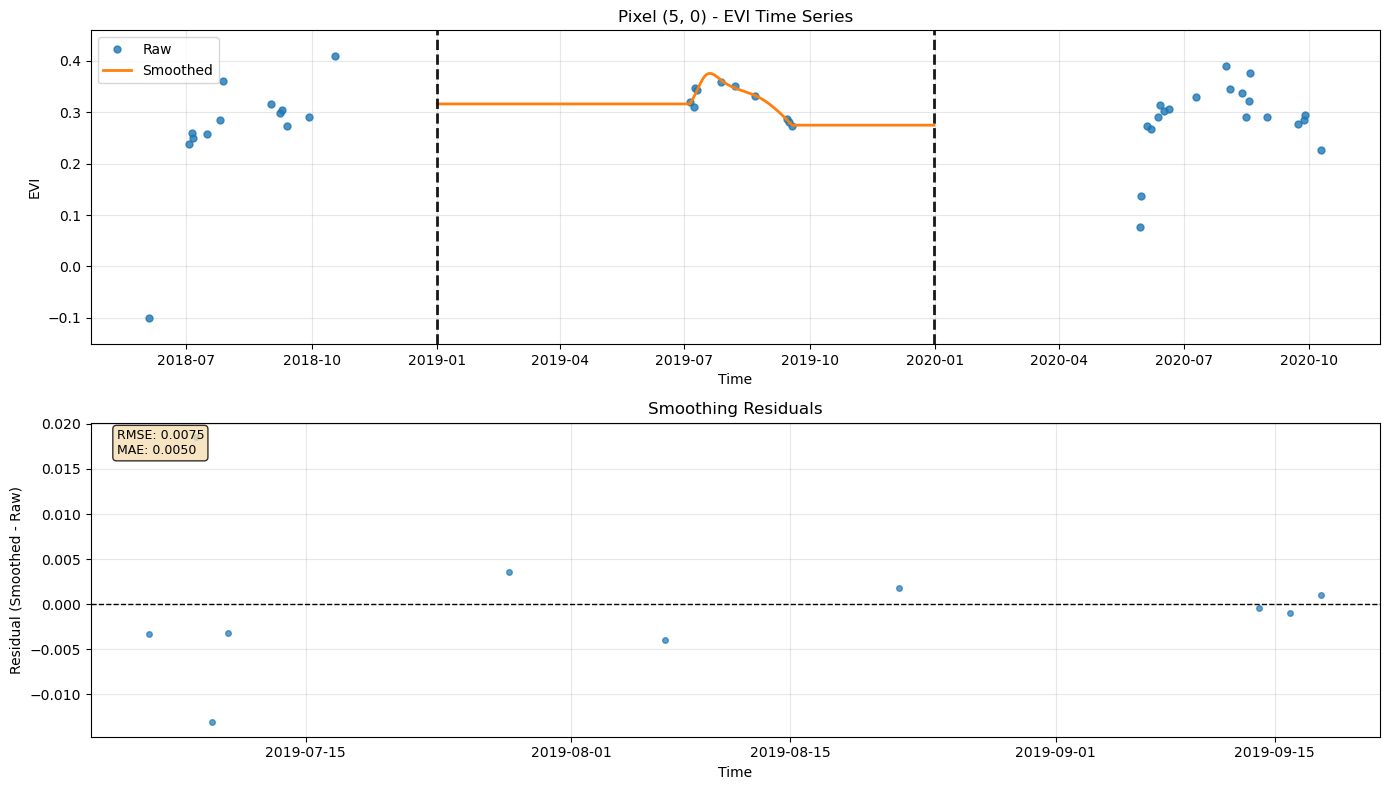


Pixel (5, 0) summary:
  Raw: 43 valid of 674 timesteps
  Smoothed: 365 valid
  RMSE: 0.0075, MAE: 0.0050


In [67]:
plot_spline_comparison(ds, yi=5, xi=0, target_year=target_year, outdir=output_dir)

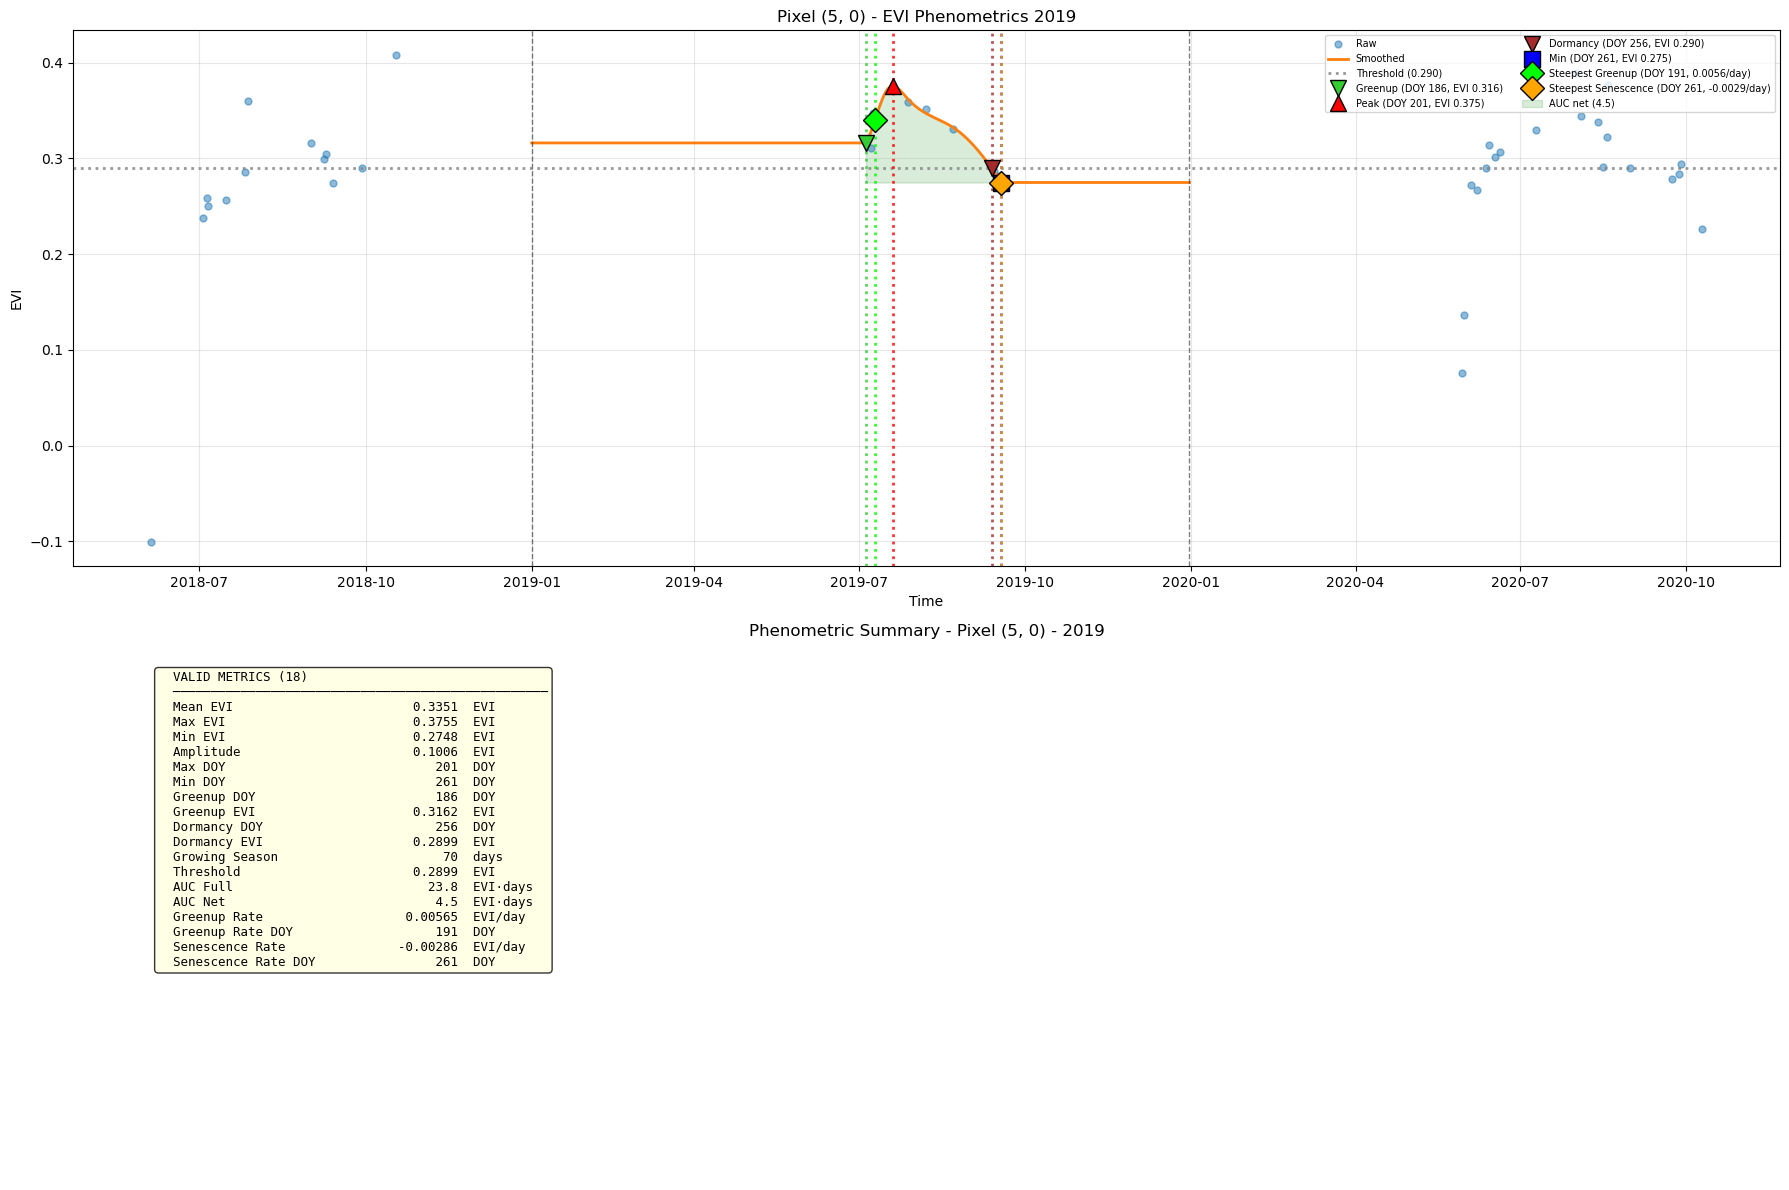

In [68]:
# Usage
plot_pixel_phenometrics(ds, chunk_results, yi=5, xi=0, target_year=2019)

In [838]:
intermediate.keys()

dict_keys(['original', 'post_threshold', 'post_despike', 'post_spline', 'post_snow_fill'])

In [918]:
# calc_obs_snow_background(ds)
x = 9
y = 9
evi_obs = intermediate['post_despike'].sel(time = str(target_year)).isel(y=y,x=x)
evi_post_spline = intermediate['post_spline'].sel(time = str(target_year)).isel(y=y,x=x)
evi_post_snow_fill = intermediate['post_snow_fill'].sel(time = str(target_year)).isel(y=y,x=x)

In [919]:
threshold = (evi_obs.min() + (evi_obs.max(dim='time', skipna=True) - evi_obs.min(dim='time', skipna=True)) * 0.05).values
threshold

array(0.16428172)

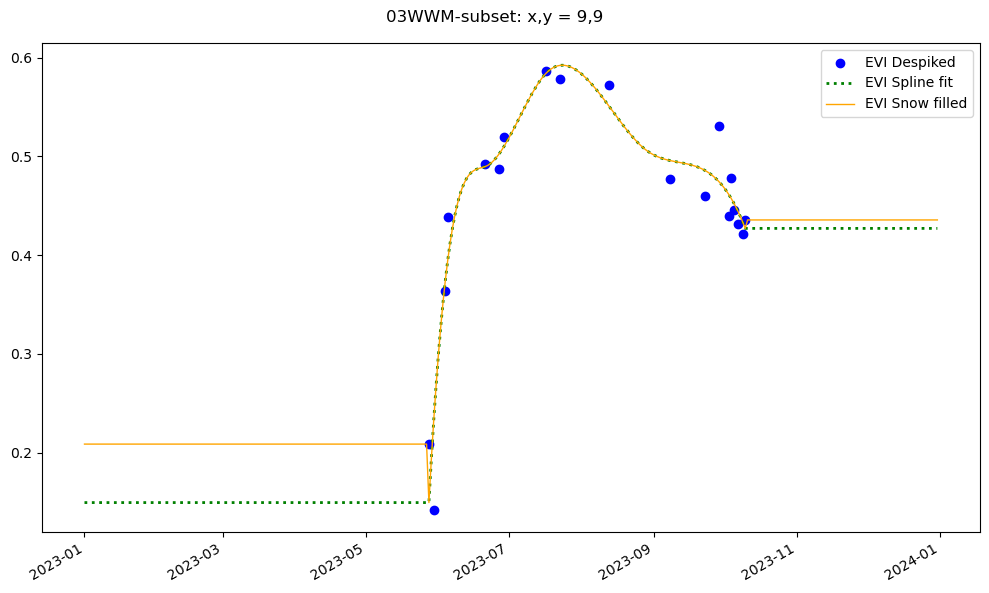

In [920]:
fig, ax = plt.subplots(figsize=(10, 6))
# ax.axhline(y = threshold, label = f"Threshold:{threshold:.2f}")
ax.scatter(evi_obs.time, evi_obs.values, label = 'EVI Despiked', color = 'blue')
ax.plot(evi_post_spline.time, evi_post_spline.values, label = 'EVI Spline fit', linewidth = 2, color = 'green', linestyle = ':')
ax.plot(evi_post_snow_fill.time, evi_post_snow_fill.values, label = 'EVI Snow filled',  linewidth = 1, color = 'orange')

# Add labels/titles
plt.suptitle(f"{tile}: x,y = {x},{y}")
plt.legend()
plt.gcf().autofmt_xdate() 
plt.tight_layout() # Prevents overlap
plt.show()

In [786]:
evi_obs.time

<xarray.DataArray 'time' (time: 161)> Size: 1kB
array(['2023-02-19T00:00:00.000000000', '2023-02-25T00:00:00.000000000',
       '2023-02-26T00:00:00.000000000', '2023-02-27T00:00:00.000000000',
       '2023-02-28T00:00:00.000000000', '2023-03-02T00:00:00.000000000',
       '2023-03-03T00:00:00.000000000', '2023-03-07T00:00:00.000000000',
       '2023-03-08T00:00:00.000000000', '2023-03-09T00:00:00.000000000',
       '2023-03-12T00:00:00.000000000', '2023-03-13T00:00:00.000000000',
       '2023-03-14T00:00:00.000000000', '2023-03-15T00:00:00.000000000',
       '2023-03-16T00:00:00.000000000', '2023-03-17T00:00:00.000000000',
       '2023-03-18T00:00:00.000000000', '2023-03-19T00:00:00.000000000',
       '2023-03-21T00:00:00.000000000', '2023-03-23T00:00:00.000000000',
       '2023-03-24T00:00:00.000000000', '2023-03-27T00:00:00.000000000',
       '2023-03-28T00:00:00.000000000', '2023-03-30T00:00:00.000000000',
       '2023-03-31T00:00:00.000000000', '2023-04-02T00:00:00.000000000',
       '2023-04-05T00:00:00.000000000', '2023-04-06T00:00:00.000000000',
       '2023-04-07T00:00:00.000000000', '2023-04-08T00:00:00.000000000',
       '2023-04-09T00:00:00.000000000', '2023-04-10T00:00:00.000000000',
       '2023-04-12T00:00:00.000000000', '2023-04-15T00:00:00.000000000',
       '2023-04-16T00:00:00.000000000', '2023-04-17T00:00:00.000000000',
       '2023-04-18T00:00:00.000000000', '2023-04-20T00:00:00.000000000',
       '2023-04-21T00:00:00.000000000', '2023-04-22T00:00:00.000000000',
       '2023-04-23T00:00:00.000000000', '2023-04-24T00:00:00.000000000',
       '2023-04-25T00:00:00.000000000', '2023-04-26T00:00:00.000000000',
       '2023-04-27T00:00:00.000000000', '2023-05-01T00:00:00.000000000',
       '2023-05-02T00:00:00.000000000', '2023-05-03T00:00:00.000000000',
       '2023-05-04T00:00:00.000000000', '2023-05-06T00:00:00.000000000',
       '2023-05-07T00:00:00.000000000', '2023-05-08T00:00:00.000000000',
       '2023-05-09T00:00:00.000000000', '2023-05-10T00:00:00.000000000',
       '2023-05-11T00:00:00.000000000', '2023-05-12T00:00:00.000000000',
       '2023-05-17T00:00:00.000000000', '2023-05-18T00:00:00.000000000',
       '2023-05-19T00:00:00.000000000', '2023-05-20T00:00:00.000000000',
       '2023-05-21T00:00:00.000000000', '2023-05-22T00:00:00.000000000',
       '2023-05-23T00:00:00.000000000', '2023-05-25T00:00:00.000000000',
       '2023-05-26T00:00:00.000000000', '2023-05-27T00:00:00.000000000',
       '2023-05-28T00:00:00.000000000', '2023-05-30T00:00:00.000000000',
       '2023-05-31T00:00:00.000000000', '2023-06-01T00:00:00.000000000',
       '2023-06-02T00:00:00.000000000', '2023-06-03T00:00:00.000000000',
       '2023-06-04T00:00:00.000000000', '2023-06-05T00:00:00.000000000',
       '2023-06-07T00:00:00.000000000', '2023-06-09T00:00:00.000000000',
       '2023-06-10T00:00:00.000000000', '2023-06-11T00:00:00.000000000',
       '2023-06-12T00:00:00.000000000', '2023-06-14T00:00:00.000000000',
       '2023-06-15T00:00:00.000000000', '2023-06-16T00:00:00.000000000',
       '2023-06-18T00:00:00.000000000', '2023-06-19T00:00:00.000000000',
       '2023-06-20T00:00:00.000000000', '2023-06-21T00:00:00.000000000',
       '2023-06-22T00:00:00.000000000', '2023-06-24T00:00:00.000000000',
       '2023-06-26T00:00:00.000000000', '2023-06-27T00:00:00.000000000',
       '2023-06-29T00:00:00.000000000', '2023-06-30T00:00:00.000000000',
       '2023-07-01T00:00:00.000000000', '2023-07-02T00:00:00.000000000',
       '2023-07-04T00:00:00.000000000', '2023-07-05T00:00:00.000000000',
       '2023-07-06T00:00:00.000000000', '2023-07-11T00:00:00.000000000',
       '2023-07-15T00:00:00.000000000', '2023-07-17T00:00:00.000000000',
       '2023-07-23T00:00:00.000000000', '2023-07-24T00:00:00.000000000',
       '2023-07-28T00:00:00.000000000', '2023-07-30T00:00:00.000000000',
       '2023-07-31T00:00:00.000000000', '2023-08-03T00:00:00.000000000',
       '2023-08-05T00:00:00.000000000', '2023-08-06T00:00:00.000000000',
       '20

In [787]:
evi_obs.values

array([       nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan, 0.08885562, 0.20390593,        

In [788]:
plt.imshow(fit_evi_fill[0], cmap='viridis', vmin=-0.2, vmax=0.8) # cmap changes the color scheme
plt.colorbar() # Adds a color scale bar
plt.show()

NameError: name 'fit_evi_fill' is not defined

In [789]:
for metric, arr in chunk_results.items():
    if isinstance(arr, np.ndarray):
        if arr.ndim == 3:
            val = arr[0, 0, 1]  # (year, y, x)
        elif arr.ndim == 2:
            val = arr[0, 1]     # (y, x)
        else:
            val = arr
        print(f"{metric:<25} {val:.4f}" if not np.isnan(val) else f"{metric:<25} NaN")

mean_evi_2023             0.5335
max_evi_2023              0.7355
min_evi_2023              0.1877
max_doy_2023              197.0000
amplitude_2023            0.5478
greenup_doy_2023          157.0000
dormancy_doy_2023         280.0000
growing_season_length_2023 123.0000
min_doy_2023              150.0000
greenup_evi_2023          0.2934
dormancy_evi_2023         0.2699
greenup_threshold_2023    0.2699
auc_full_2023             69.5736
auc_net_2023              46.4839
greenup_rate_2023         0.0264
greenup_rate_doy_2023     160.0000
senescence_rate_2023      -0.0081
senescence_rate_doy_2023  283.0000
mean_revisit_time_2023    7.5000
quality_pixel_cnt_2023    19.0000


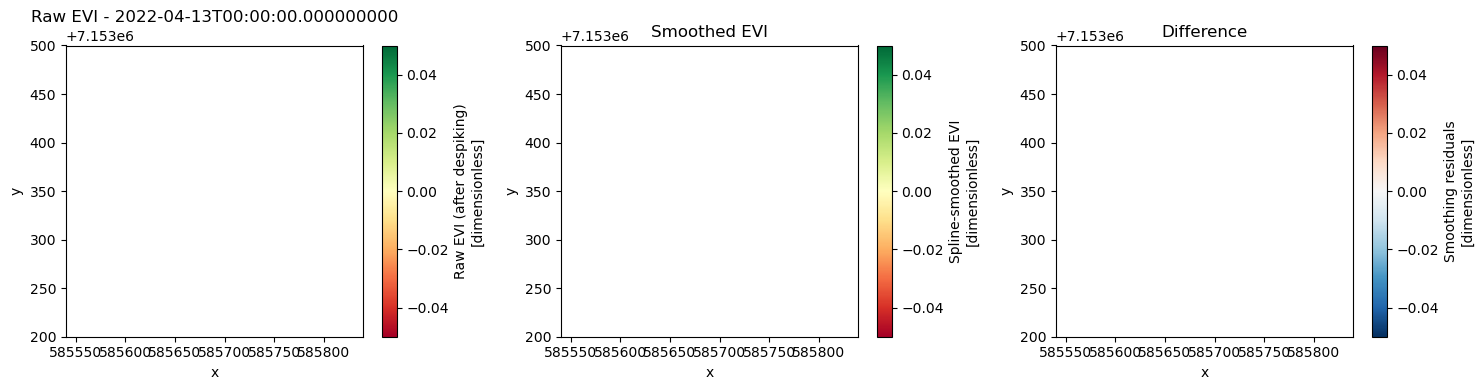

In [790]:
# Or plot spatial maps for a specific date
date_idx = 37
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ds['evi_raw'].isel(time=date_idx).plot(ax=axes[0], cmap='RdYlGn')
axes[0].set_title(f'Raw EVI - {ds.time.values[date_idx]}')

ds['evi_smoothed'].isel(time=date_idx).plot(ax=axes[1], cmap='RdYlGn')
axes[1].set_title('Smoothed EVI')

ds['difference'].isel(time=date_idx).plot(ax=axes[2], cmap='RdBu_r', center=0)
axes[2].set_title('Difference')

plt.tight_layout()
# plt.savefig('spatial_comparison.png', dpi=150)

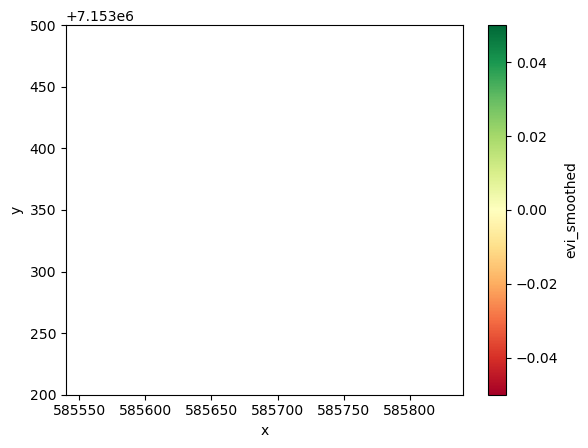

In [791]:
date_idx = 37 + 8
diff = ds['evi_smoothed'].isel(time=date_idx) - ds['evi_smoothed'].isel(time=date_idx + 1)

diff.plot(cmap='RdYlGn')

In [ ]:
# Example 1: Calculate metrics from NetCDF
y = "2020"
metrics = calculate_smoothing_metrics(
    netcdf_path=Path(f"{output_dir}/spline_comparison_{y}.nc"),
    raw_var='evi_raw',
    smoothed_var='evi_smoothed',
    target_year=target_year,
)

# Save metrics
# metrics.to_netcdf("./smoothing_metrics_2017.nc")
# print("Metrics saved to smoothing_metrics_2017.nc")
plot_error_metrics(metrics, output_dir=f"{output_dir}/",target_year=target_year)

In [ ]:
# # Example 2: Generate diagnostic plots

#     # Example 3: Access specific metrics
#     print(f"\nPixel with highest RMSE: {float(metrics['rmse'].max().values):.4f}")
#     print(f"Pixel with lowest correlation: {float(metrics['correlation'].min().values):.4f}")
    
#     # Example 4: Export summary to CSV
#     import pandas as pd
    
#     summary_df = pd.DataFrame({
#         'Metric': ['RMSE', 'MAE', 'MBE', 'Correlation', 'NSE'],
#         'Value': [
#             metrics.attrs['global_rmse'],
#             metrics.attrs['global_mae'],
#             metrics.attrs['global_mbe'],
#             metrics.attrs['global_r'],
#             metrics.attrs['global_nse']
#         ]
#     })
    
#     summary_df.to_csv('./smoothing_summary.csv', index=False)
#     print("\nSummary exported to smoothing_summary.csv")

In [ ]:
# Compute the mean ROI EVI curves?
if TIMESERIES:
    print("\n" + "=" * 60)
    print("  NLCD-Stratified mean ROI Time Series")
    print("=" * 60)

    # smaller function that skips phenometrics
    _, roi_ts = reader.enter_processing_stage(
        min_evi=-0.2, max_evi=1.0, interp_method='cubic',
        skip_pixel_processing=True,
        skip_timeseries=False,
        timeseries_output_dir=output_dir,
    )

    plot_roi_timeseries_by_code(
        roi_ts, save_dir=output_dir / "plots", top_n=10, layout="facet"
    )

# Compute the annual phenometrics?
if PHENOMETRICS:
    print("\n" + "=" * 60)
    print(" Annual Phenometrics")
    print("=" * 60)

    # Loop over each year
    all_year_results = {}
    for central_year in range(start_year, end_year + 1):
        print(f"Processing phenometrics for {central_year}...")

            # Specify configuration for phenometrics calculations
            configured_pipeline = partial(
                full_pipeline_chunk,
                apply_threshold=True, # do not clip EVI values 
                min_evi_threshold=-1, # threshold
                max_evi_threshold=1.0,  # threshold 
                clip_evi=False,        # Not Bolton method
                is_monthly=is_monthly, 
                despike=despike,
                despike_max_gap=45, 
                despike_abs_threshold=0.1,
                despike_rel_threshold=2.0,
                central_year
            )

        pixels, _ = reader.enter_processing_stage(
            process_fn=configured_pipeline,
            chunks_in_memory=8,     # Increase if more Mem avail
            skip_timeseries=True,
            skip_pixel_processing=False,
        )

        all_year_results[year] = year_results

    
    # Save combined results
    for year, pixels in all_year_results.items():
        save_results_with_timeseries(
            pixels,
            None,
            output_dir / f"phenometrics_{year}",
            y_coords=reader.y_coords,
            x_coords=reader.x_coords,
            crs=reader.crs,
        )
    
    save_results_with_timeseries(
        pixels, 
        None, 
        output_dir,
        y_coords=reader.y_coords, a
        x_coords=reader.x_coords,
        crs=reader.crs,
    )
print("COMPLETE")

In [ ]:
plot_roi_timeseries_by_code(
    roi_timeseries,
    save_dir=output_dir / "plots",
    top_n=10,
    layout="facet",
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_all_pixels_with_mean(ds, target_year=None, ylim_evi=None, ylim_resid=None):
    """
    Plot all pixel curves with mean overlay.
    
    Args:
        ds: xarray Dataset with evi_raw, evi_smoothed, difference
        target_year: Optional year to highlight
        ylim_evi: Optional (min, max) for EVI axis
        ylim_resid: Optional (min, max) for residual axis
    """
    ny = len(ds.y)
    nx = len(ds.x)
    n_pixels = ny * nx
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Storage for computing mean curves
    all_raw_times = []
    all_raw_values = []
    all_smooth_times = []
    all_smooth_values = []
    all_diff_times = []
    all_diff_values = []
    
    n_valid_pixels = 0
    
    for yi in range(ny):
        for xi in range(nx):
            # Extract and drop NaN
            raw = ds['evi_raw'].isel(y=yi, x=xi).dropna(dim='time')
            smoothed = ds['evi_smoothed'].isel(y=yi, x=xi).dropna(dim='time')
            diff = ds['difference'].isel(y=yi, x=xi).dropna(dim='time')
            
            # Skip all-NaN pixels
            if len(raw) < 5 or len(smoothed) < 5:
                continue
            
            n_valid_pixels += 1
            
            # Plot individual curves (light, semi-transparent)
            ax1.plot(raw.time.values, raw.values, 'o', 
                    markersize=2, alpha=0.1, color='C0')
            ax1.plot(smoothed.time.values, smoothed.values, '-', 
                    linewidth=0.5, alpha=0.1, color='C1')
            
            ax2.plot(diff.time.values, diff.values, 'o',
                    markersize=2, alpha=0.15, color='C0')
            
            # Store for mean calculation
            all_raw_times.append(raw.time.values)
            all_raw_values.append(raw.values)
            all_smooth_times.append(smoothed.time.values)
            all_smooth_values.append(smoothed.values)
            all_diff_times.append(diff.time.values)
            all_diff_values.append(diff.values)
    
    print(f"Valid pixels: {n_valid_pixels}/{n_pixels}")
    
    # ================================================================
    # Calculate mean curves by binning to common time grid
    # ================================================================
    
    # Create common time grid (all unique dates)
    all_times_flat = np.concatenate(all_smooth_times)
    unique_times = np.sort(np.unique(all_times_flat))
    
    # Bin values to common grid
    raw_binned = np.full((n_valid_pixels, len(unique_times)), np.nan)
    smooth_binned = np.full((n_valid_pixels, len(unique_times)), np.nan)
    diff_binned = np.full((n_valid_pixels, len(unique_times)), np.nan)
    
    for i in range(n_valid_pixels):
        # Raw
        for j, t in enumerate(all_raw_times[i]):
            idx = np.searchsorted(unique_times, t)
            if idx < len(unique_times) and unique_times[idx] == t:
                raw_binned[i, idx] = all_raw_values[i][j]
        
        # Smoothed
        for j, t in enumerate(all_smooth_times[i]):
            idx = np.searchsorted(unique_times, t)
            if idx < len(unique_times) and unique_times[idx] == t:
                smooth_binned[i, idx] = all_smooth_values[i][j]
        
        # Difference
        for j, t in enumerate(all_diff_times[i]):
            idx = np.searchsorted(unique_times, t)
            if idx < len(unique_times) and unique_times[idx] == t:
                diff_binned[i, idx] = all_diff_values[i][j]
    
    # Calculate mean and std (ignoring NaN)
    raw_mean = np.nanmean(raw_binned, axis=0)
    raw_std = np.nanstd(raw_binned, axis=0)
    smooth_mean = np.nanmean(smooth_binned, axis=0)
    smooth_std = np.nanstd(smooth_binned, axis=0)
    diff_mean = np.nanmean(diff_binned, axis=0)
    diff_std = np.nanstd(diff_binned, axis=0)
    
    # Count valid pixels per timestep
    raw_count = np.sum(~np.isnan(raw_binned), axis=0)
    smooth_count = np.sum(~np.isnan(smooth_binned), axis=0)
    
    # Mask timesteps with too few pixels
    min_pixels = 3
    raw_mask = raw_count >= min_pixels
    smooth_mask = smooth_count >= min_pixels
    
    # ================================================================
    # Plot mean curves
    # ================================================================
    
    # Mean raw
    ax1.plot(unique_times[raw_mask], raw_mean[raw_mask], 'o',
            markersize=5, color='C0', label=f'Raw mean (n={n_valid_pixels})', zorder=5)
    
    # Mean smoothed with confidence band
    ax1.plot(unique_times[smooth_mask], smooth_mean[smooth_mask], '-',
            linewidth=3, color='C1', label='Smoothed mean', zorder=5)
    ax1.fill_between(
        unique_times[smooth_mask],
        (smooth_mean - smooth_std)[smooth_mask],
        (smooth_mean + smooth_std)[smooth_mask],
        alpha=0.3, color='C1', label='±1 std'
    )
    
    # Year boundaries
    if target_year:
        ax1.axvline(pd.Timestamp(f'{target_year}-01-01'), color='black',
                   linestyle='--', linewidth=1.5, alpha=0.7)
        ax1.axvline(pd.Timestamp(f'{target_year}-12-31'), color='black',
                   linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax1.set_title(f'All Pixels ({ny}×{nx}) - EVI Time Series with Mean')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('EVI')
    ax1.set_ylim(0, 0.8)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # Mean residuals with confidence band
    diff_mask = np.sum(~np.isnan(diff_binned), axis=0) >= min_pixels
    
    ax2.plot(unique_times[diff_mask], diff_mean[diff_mask], 'o-',
            markersize=4, linewidth=2, color='C0', label='Mean residual', zorder=5)
    ax2.fill_between(
        unique_times[diff_mask],
        (diff_mean - diff_std)[diff_mask],
        (diff_mean + diff_std)[diff_mask],
        alpha=0.2, color='C0', label='±1 std'
    )
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    
    if target_year:
        ax2.axvline(pd.Timestamp(f'{target_year}-01-01'), color='black',
                   linestyle='--', linewidth=1.5, alpha=0.7)
        ax2.axvline(pd.Timestamp(f'{target_year}-12-31'), color='black',
                   linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Add stats
    valid_diff = diff_mean[diff_mask]
    rmse = np.sqrt(np.nanmean(valid_diff ** 2))
    mae = np.nanmean(np.abs(valid_diff))
    
    stats_text = (
        f'Mean RMSE: {rmse:.4f}\n'
        f'Mean MAE: {mae:.4f}\n'
        f'Pixels: {n_valid_pixels}'
    )
    ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax2.set_title('Mean Smoothing Residuals (all pixels)')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Residual (Smoothed - Raw)')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    if ylim_resid:
        ax2.set_ylim(ylim_resid)
    
    plt.tight_layout()
    # plt.savefig('all_pixels_mean.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print(f"\n{'='*50}")
    print(f"Summary Statistics (Mean across {n_valid_pixels} pixels)")
    print(f"{'='*50}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAE:   {mae:.4f}")
    print(f"MBE:   {mbe:+.4f}")


# Usage
plot_all_pixels_with_mean(ds.sel(time="2020"), target_year=2020)
# plot_all_pixels_with_mean(ds, target_year=2019, ylim_evi=(-0.1, 0.8), ylim_resid=(-0.15, 0.15))

# TESTING lighter weight workflow

In [ ]:
# pseudo code
1) loop into chunk
2) load all dates
3) preproc/despike/spline
4) compute phenometrics
5) save chunk

- split full_pipeline_chunk into two funcs (preprocess and annualpheno)

in process_all_chunks:
 chunk = load_chunk(...)
 chunk_smooth = preprocess_chunk(chunk, ...)
 metrics = annual_phenometrics_chunk(chunk_smooth, ...)



chunk_all = load full chunk once
for year in years:
    year_window = subset chunk_all to year ± buffer
    year_smooth = spline(year_window)
    central_year = subset year_smooth to target year only
    metrics[year] = compute phenometrics(central_year)

In [ ]:
def get_dates_for_center_year(self, year, buffer_years=1):
    available_years = sorted(set(d.year for d in self.unique_dates))
    years_to_load = [y for y in [year-buffer_years, year, year+buffer_years] if y in available_years]
    return [pd.Timestamp(d) for d in self.unique_dates if d.year in years_to_load]

    
for year in year_list:
    dates_window = reader.get_dates_for_center_year(year, buffer_years=1)


    # this will replace process_all_chunks and some of the process_single_chunk logic
    for chunk_idx in range(reader.n_chunks):
        evi_chunk, doy_chunk, comp_start = reader.load_chunk(
            chunk_idx, dates_subset=dates_window
        )
        
        results = annual_phenometrics_chunk(
            evi_chunk,
            doy_data=doy_chunk,
            years=[year],
            composite_start_doys=comp_start,
            ...
        )
        
        write_chunk_results(...)

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

def create_mock_evi_dataset(
    ny: int = 5,
    nx: int = 5,
    year: int = 2019,
    composite_interval: int = 10,
    noise_level: float = 0.02,
    seed: int = 42
) -> tuple[xr.DataArray, xr.DataArray, np.ndarray]:
    """
    Create a mock 10-day composite EVI dataset with known phenology.
    
    Returns:
        evi_da: EVI DataArray (time, y, x)
        doy_da: DOY offset DataArray (time, y, x)
        composite_start_doys: Array of composite start DOYs
    """
    np.random.seed(seed)
    
    # Create 10-day composite dates for one year
    composite_start_doys = np.arange(1, 366, composite_interval)  # [1, 11, 21, ...]
    n_dates = len(composite_start_doys)
    
    # Create time coordinates
    dates = pd.date_range(f"{year}-01-01", periods=n_dates, freq=f"{composite_interval}D")
    # Ensure we don't go past Dec 31
    dates = dates[dates.year == year]
    composite_start_doys = composite_start_doys[:len(dates)]
    n_dates = len(dates)
    
    print(f"Mock dataset: {n_dates} dates, {ny}x{nx} pixels")
    print(f"Date range: {dates[0].date()} to {dates[-1].date()}")
    
    # =========================================================================
    # Define known phenology parameters per pixel
    # =========================================================================
    
    # Create a grid of phenology parameters
    phenology_params = np.zeros((ny, nx), dtype=[
        ('min_evi', float),
        ('max_evi', float),
        ('greenup_doy', float),
        ('peak_doy', float),
        ('senescence_doy', float),
        ('dormancy_doy', float),
    ])
    
    for yi in range(ny):
        for xi in range(nx):
            # Vary phenology across pixels
            lat_factor = yi / max(ny - 1, 1)  # 0 to 1 (south to north)
            lon_factor = xi / max(nx - 1, 1)  # 0 to 1 (west to east)
            
            phenology_params[yi, xi] = (
                0.10 + 0.05 * lat_factor,                    # min_evi: 0.10-0.15
                0.55 + 0.15 * lat_factor + 0.05 * lon_factor, # max_evi: 0.55-0.75
                90 + 20 * lat_factor,                         # greenup_doy: 90-110
                180 + 15 * lat_factor,                        # peak_doy: 180-195
                260 - 10 * lat_factor,                        # senescence_doy: 250-260
                310 + 15 * lat_factor,                        # dormancy_doy: 310-325
            )
    
    # =========================================================================
    # Generate EVI values using double logistic function
    # =========================================================================
    
    evi_data = np.full((n_dates, ny, nx), np.nan, dtype=np.float32)
    doy_offset_data = np.zeros((n_dates, ny, nx), dtype=np.float32)
    
    for yi in range(ny):
        for xi in range(nx):
            p = phenology_params[yi, xi]
            
            min_evi = p['min_evi']
            max_evi = p['max_evi']
            greenup_center = p['greenup_doy']
            peak_doy = p['peak_doy']
            senescence_center = p['senescence_doy']
            
            amplitude = max_evi - min_evi
            
            for t_idx in range(n_dates):
                comp_start = composite_start_doys[t_idx]
                
                # Random DOY offset within composite (0-9)
                doy_offset = np.random.randint(0, min(composite_interval, 10))
                doy_offset_data[t_idx, yi, xi] = doy_offset
                
                actual_doy = comp_start + doy_offset
                
                # Double logistic model
                # Greenup: sigmoid rise
                greenup_rate_param = 0.06 + 0.02 * np.random.randn()
                senescence_rate_param = 0.04 + 0.01 * np.random.randn()
                
                rise = 1.0 / (1.0 + np.exp(-greenup_rate_param * (actual_doy - greenup_center)))
                fall = 1.0 / (1.0 + np.exp(senescence_rate_param * (actual_doy - senescence_center)))
                
                evi_value = min_evi + amplitude * rise * fall
                
                # Add noise
                evi_value += noise_level * np.random.randn()
                
                # Clip to realistic range
                evi_value = np.clip(evi_value, -0.1, 1.0)
                
                evi_data[t_idx, yi, xi] = evi_value
    
    # =========================================================================
    # Introduce some realistic data issues
    # =========================================================================
    
    # 1. Add some cloud-contaminated observations (spikes down)
    n_clouds = int(n_dates * ny * nx * 0.05)  # 5% of observations
    for _ in range(n_clouds):
        t_idx = np.random.randint(0, n_dates)
        y_idx = np.random.randint(0, ny)
        x_idx = np.random.randint(0, nx)
        evi_data[t_idx, y_idx, x_idx] *= 0.3  # Reduce by 70%
    
    # 2. Add some NaN gaps (missing observations)
    n_gaps = int(n_dates * ny * nx * 0.08)  # 8% missing
    for _ in range(n_gaps):
        t_idx = np.random.randint(0, n_dates)
        y_idx = np.random.randint(0, ny)
        x_idx = np.random.randint(0, nx)
        evi_data[t_idx, y_idx, x_idx] = np.nan
    
    # 3. Make one pixel all-NaN (water/urban)
    evi_data[:, 0, 0] = np.nan
    
    # =========================================================================
    # Create xarray DataArrays
    # =========================================================================
    
    y_coords = np.arange(ny) * 30.0 + 4293000.0  # Fake UTM coordinates
    x_coords = np.arange(nx) * 30.0 + 300800.0
    
    evi_da = xr.DataArray(
        evi_data,
        dims=['time', 'y', 'x'],
        coords={
            'time': dates,
            'y': y_coords,
            'x': x_coords
        },
        name='evi'
    )
    
    doy_da = xr.DataArray(
        doy_offset_data,
        dims=['time', 'y', 'x'],
        coords={
            'time': dates,
            'y': y_coords,
            'x': x_coords
        },
        name='doy_offset'
    )
    
    print(f"\nEVI shape: {evi_da.shape}")
    print(f"DOY shape: {doy_da.shape}")
    print(f"Composite start DOYs: {composite_start_doys[:5]}... ({len(composite_start_doys)} total)")
    print(f"NaN fraction: {np.isnan(evi_data).mean():.2%}")
    print(f"All-NaN pixels: {np.all(np.isnan(evi_data), axis=0).sum()}")
    
    return evi_da, doy_da, composite_start_doys, phenology_params


def validate_phenometrics(results: dict, params, ny: int, nx: int):
    """
    Compare calculated phenometrics against known parameters.
    """
    
    print("\n" + "=" * 70)
    print("PHENOMETRIC VALIDATION")
    print("=" * 70)
    
    # Expected vs actual comparison
    metrics_to_check = {
        'greenup_doy': 'greenup_doy',
        'dormancy_doy': 'dormancy_doy',
        'annual_max_doy': 'peak_doy',
        'annual_min': 'min_evi',
        'annual_max': 'max_evi',
    }
    
    for metric_name, param_name in metrics_to_check.items():
        if metric_name not in results:
            print(f"\n{metric_name}: NOT FOUND in results")
            continue
        
        result_arr = results[metric_name]
        
        # Handle (1, ny, nx) shape
        if result_arr.ndim == 3:
            result_arr = result_arr[0]
        
        print(f"\n--- {metric_name} ---")
        print(f"{'Pixel':<10} {'Expected':<12} {'Calculated':<12} {'Diff':<10} {'Status'}")
        print("-" * 60)
        
        n_valid = 0
        n_close = 0
        diffs = []
        
        for yi in range(ny):
            for xi in range(nx):
                expected = params[yi, xi][param_name]
                calculated = result_arr[yi, xi]
                
                if np.isnan(calculated):
                    status = "NaN"
                    if yi == 0 and xi == 0:
                        status = "NaN (expected - all-NaN pixel)"
                else:
                    n_valid += 1
                    diff = calculated - expected
                    diffs.append(diff)
                    
                    # DOY metrics: within 20 days is reasonable
                    if 'doy' in metric_name.lower():
                        tolerance = 20
                    else:
                        tolerance = 0.1  # EVI tolerance
                    
                    if abs(diff) < tolerance:
                        status = "✓ PASS"
                        n_close += 1
                    else:
                        status = f"✗ FAIL (diff={diff:.1f})"
                    
                    diff_str = f"{diff:+.2f}"
                
                # Print first few and any failures
                if yi * nx + xi < 5 or 'FAIL' in status:
                    calc_str = f"{calculated:.2f}" if not np.isnan(calculated) else "NaN"
                    print(f"({yi},{xi}){'':<5} {expected:<12.2f} {calc_str:<12} {diff_str if not np.isnan(calculated) else 'N/A':<10} {status}")
        
        if diffs:
            diffs = np.array(diffs)
            print(f"\nSummary: {n_close}/{n_valid} within tolerance")
            print(f"  Mean diff: {np.mean(diffs):+.2f}")
            print(f"  Std diff:  {np.std(diffs):.2f}")
            print(f"  Max abs diff: {np.max(np.abs(diffs)):.2f}")
    
    # Check new metrics
    print("\n\n--- ADVANCED METRICS CHECK ---")
    
    advanced_metrics = ['auc_full', 'auc_net', 'greenup_rate', 'greenup_rate_doy',
                       'senescence_rate', 'senescence_rate_doy', 'mean_revisit_time']
    
    for metric_name in advanced_metrics:
        if metric_name not in results:
            print(f"{metric_name}: NOT FOUND")
            continue
        
        arr = results[metric_name]
        if arr.ndim == 3:
            arr = arr[0]
        
        n_valid = np.sum(~np.isnan(arr))
        n_total = arr.size
        
        print(f"\n{metric_name}:")
        print(f"  Valid: {n_valid}/{n_total} pixels ({n_valid/n_total*100:.1f}%)")
        
        if n_valid > 0:
            valid_vals = arr[~np.isnan(arr)]
            print(f"  Range: [{np.min(valid_vals):.4f}, {np.max(valid_vals):.4f}]")
            print(f"  Mean: {np.mean(valid_vals):.4f}")
            print(f"  Std: {np.std(valid_vals):.4f}")
            
            # Sanity checks
            if metric_name == 'auc_full':
                if np.all(valid_vals > 0):
                    print(f"  ✓ All positive (expected for EVI integral)")
                else:
                    print(f"  ✗ Some negative values!")
            
            elif metric_name == 'auc_net':
                if np.all(valid_vals >= 0):
                    print(f"  ✓ All non-negative (above baseline)")
                else:
                    print(f"  ✗ Some negative values!")
                
                # AUC net should be less than AUC full
                if 'auc_full' in results:
                    auc_f = results['auc_full']
                    if auc_f.ndim == 3:
                        auc_f = auc_f[0]
                    both_valid = ~np.isnan(arr) & ~np.isnan(auc_f)
                    if np.all(arr[both_valid] <= auc_f[both_valid]):
                        print(f"  ✓ AUC net ≤ AUC full for all pixels")
                    else:
                        print(f"  ✗ AUC net > AUC full for some pixels!")
            
            elif metric_name == 'greenup_rate':
                if np.all(valid_vals > 0):
                    print(f"  ✓ All positive (increasing EVI)")
                else:
                    print(f"  ✗ Some negative values!")
            
            elif metric_name == 'senescence_rate':
                if np.all(valid_vals < 0):
                    print(f"  ✓ All negative (decreasing EVI)")
                else:
                    print(f"  ✗ Some positive values!")
            
            elif metric_name == 'greenup_rate_doy':
                greenup = results.get('greenup_doy')
                peak = results.get('annual_max_doy')
                if greenup is not None and peak is not None:
                    if greenup.ndim == 3: greenup = greenup[0]
                    if peak.ndim == 3: peak = peak[0]
                    all_valid = ~np.isnan(arr) & ~np.isnan(greenup) & ~np.isnan(peak)
                    if np.all((arr[all_valid] >= greenup[all_valid]) & 
                             (arr[all_valid] <= peak[all_valid])):
                        print(f"  ✓ Between greenup and peak DOY")
                    else:
                        print(f"  ✗ Some values outside greenup-peak range")
            
            elif metric_name == 'senescence_rate_doy':
                peak = results.get('annual_max_doy')
                dormancy = results.get('dormancy_doy')
                if peak is not None and dormancy is not None:
                    if peak.ndim == 3: peak = peak[0]
                    if dormancy.ndim == 3: dormancy = dormancy[0]
                    all_valid = ~np.isnan(arr) & ~np.isnan(peak) & ~np.isnan(dormancy)
                    if np.all((arr[all_valid] >= peak[all_valid]) & 
                             (arr[all_valid] <= dormancy[all_valid])):
                        print(f"  ✓ Between peak and dormancy DOY")
                    else:
                        print(f"  ✗ Some values outside peak-dormancy range")
            
            elif metric_name == 'mean_revisit_time':
                if np.all(valid_vals > 0) and np.all(valid_vals < 100):
                    print(f"  ✓ Reasonable range (expected ~10 days for 10-day composites)")
                else:
                    print(f"  ✗ Unexpected values!")


def plot_mock_results(evi_da, results, params, pixel=(2, 2)):
    """Plot results for a single pixel."""
    
    yi, xi = pixel
    p = params[yi, xi]
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # --- Plot 1: Time series with phenometric markers ---
    ax = axes[0]
    
    # Raw EVI
    pixel_evi = evi_da.isel(y=yi, x=xi)
    ax.plot(pixel_evi.time, pixel_evi.values, 'o-', alpha=0.7, label='Raw EVI', markersize=4)
    
    # Mark known phenology
    for doy, label, color in [
        (p['greenup_doy'], 'True Greenup', 'green'),
        (p['peak_doy'], 'True Peak', 'red'),
        (p['senescence_doy'], 'True Senescence', 'orange'),
        (p['dormancy_doy'], 'True Dormancy', 'brown'),
    ]:
        date = pd.Timestamp(f"2019-01-01") + pd.Timedelta(days=int(doy)-1)
        ax.axvline(date, color=color, linestyle=':', alpha=0.5, label=f'{label} (DOY {doy:.0f})')
    
    # Mark calculated phenology
    calc_markers = {
        'greenup_doy': ('v', 'green', 'Calc Greenup'),
        'dormancy_doy': ('v', 'brown', 'Calc Dormancy'),
        'annual_max_doy': ('^', 'red', 'Calc Peak'),
    }
    
    for metric, (marker, color, label) in calc_markers.items():
        if metric in results:
            val = results[metric]
            if val.ndim == 3: val = val[0]
            doy = val[yi, xi]
            if not np.isnan(doy):
                date = pd.Timestamp(f"2019-01-01") + pd.Timedelta(days=int(doy)-1)
                ax.axvline(date, color=color, linestyle='--', alpha=0.8)
                ax.plot(date, results['annual_max' if 'max' in metric else 'greenup_evi' if 'greenup' in metric else 'dormancy_evi'][0, yi, xi] if metric != 'annual_max_doy' else results['annual_max'][0, yi, xi],
                       marker, color=color, markersize=12, label=f'{label} (DOY {doy:.0f})', zorder=5)
    
    ax.set_title(f'Pixel ({yi}, {xi}) - EVI Time Series with Phenometrics')
    ax.set_xlabel('Date')
    ax.set_ylabel('EVI')
    ax.legend(fontsize=8, ncol=2, loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # --- Plot 2: Advanced metrics visualization ---
    ax2 = axes[1]
    
    # Show derivative (rate of change)
    pixel_vals = pixel_evi.values
    valid = ~np.isnan(pixel_vals)
    if valid.sum() >= 5:
        doys = pixel_evi.time.dt.dayofyear.values[valid].astype(float)
        evis = pixel_vals[valid]
        
        deriv = np.gradient(evis, doys)
        dates_valid = pixel_evi.time.values[valid]
        
        ax2.plot(dates_valid, deriv, 'o-', alpha=0.7, label='dEVI/dt', markersize=4)
        ax2.axhline(0, color='black', linestyle='--', alpha=0.3)
        
        # Mark inflection points
        if 'greenup_rate_doy' in results:
            grd = results['greenup_rate_doy']
            gr = results['greenup_rate']
            if grd.ndim == 3: grd = grd[0]
            if gr.ndim == 3: gr = gr[0]
            if not np.isnan(grd[yi, xi]):
                date = pd.Timestamp(f"2019-01-01") + pd.Timedelta(days=int(grd[yi, xi])-1)
                ax2.axvline(date, color='green', linestyle='--', 
                          label=f'Steepest Greenup DOY={grd[yi, xi]:.0f}, rate={gr[yi, xi]:.4f}')
        
        if 'senescence_rate_doy' in results:
            srd = results['senescence_rate_doy']
            sr = results['senescence_rate']
            if srd.ndim == 3: srd = srd[0]
            if sr.ndim == 3: sr = sr[0]
            if not np.isnan(srd[yi, xi]):
                date = pd.Timestamp(f"2019-01-01") + pd.Timedelta(days=int(srd[yi, xi])-1)
                ax2.axvline(date, color='orange', linestyle='--',
                          label=f'Steepest Senescence DOY={srd[yi, xi]:.0f}, rate={sr[yi, xi]:.4f}')
    
    ax2.set_title(f'Pixel ({yi}, {xi}) - Rate of Change (dEVI/dt)')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('EVI/day')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # Add text with AUC values
    if 'auc_full' in results and 'auc_net' in results:
        auc_f = results['auc_full'][0, yi, xi] if results['auc_full'].ndim == 3 else results['auc_full'][yi, xi]
        auc_n = results['auc_net'][0, yi, xi] if results['auc_net'].ndim == 3 else results['auc_net'][yi, xi]
        rt = results['mean_revisit_time'][0, yi, xi] if results['mean_revisit_time'].ndim == 3 else results['mean_revisit_time'][yi, xi]
        
        text = f"AUC Full: {auc_f:.1f}\nAUC Net: {auc_n:.1f}\nRevisit: {rt:.1f} days"
        ax2.text(0.02, 0.98, text, transform=ax2.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('mock_phenometrics_test.png', dpi=150, bbox_inches='tight')
    plt.show()


# =============================================================================
# RUN THE TEST
# =============================================================================

# 1. Create mock data
evi_da, doy_da, comp_start_doys, phenology_params = create_mock_evi_dataset(
    ny=5, nx=5, year=2019, noise_level=0.02
)

# 2. Run phenometrics
results = annual_phenometrics_chunk(
    chunk=evi_da,
    doy_data=doy_da,
    year=2019,
    threshold_greenup_pct=0.15,
    is_monthly=False,
    composite_start_doys=comp_start_doys
)

# 3. Validate results
validate_phenometrics(results, phenology_params, ny=5, nx=5)

# 4. Plot results
plot_mock_results(evi_da, results, phenology_params, pixel=(2, 2))

# OLD CODE